In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace,correct_trace_whole_trial
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,angle_to_open_corner,turn_direction_left_right
from pipeline.oa_calculations import *
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [2]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [156]:
def get_median_trajectory(df, x_key: str, y_key: str, 
                         turn_direction_key: str = 'turn_direction_left_right',
                         start_position_key: str = 'start',
                         return_matrix=False):
    """
    Calculate median trajectory by interpolating y-values into distance bins.
    Adjusts bins based on turn direction and starting position.
    
    Parameters:
    - df: Input DataFrame containing trajectory data
    - x_key: Column name for x-coordinates (distance)
    - y_key: Column name for y-coordinates (to be interpolated)
    - turn_direction_key: Column name containing turn direction ('left' or 'right')
    - start_position_key: Column name containing start position ('bottom_left' or 'bottom_right')
    - return_matrix: If True, returns both median and all interpolated trajectories
    
    Returns:
    - Median trajectory (and optionally all trajectories)
    """
    # Determine turn direction and start position (assuming all rows are consistent)
    turn_direction = df[turn_direction_key].iloc[0].lower()
   
    
   ## Set distance bins based on turn direction and start position
   #if turn_direction == 'left' and start_position == 'bottom':
   #    distance_bins = np.arange(9, 50, 1)    # Left turns from bottom left
   #elif turn_direction == 'right' and start_position == 'bottom':
   #    distance_bins = np.arange(45, 0, -1)   # Right turns from bottom right
   #elif turn_direction == 'left' and start_position == 'top':
   #    distance_bins = np.arange(45, 0, -1) 
   #elif turn_direction == 'right' and start_position == 'top':
   #    distance_bins = np.arange(9, 50, 1) 

        # Set distance bins based on turn direction and start position
 
    if turn_direction == 'left':
        distance_bins = np.arange(55, 13, -1)    # Left turns from bottom left
    elif turn_direction == 'right':
        distance_bins = np.arange(7, 50, 1)   # Right turns from bottom right
  
    
    # Initialize matrix to store interpolated trajectories
    trajectory_matrix = np.zeros((len(df), len(distance_bins)))
    trajectory_matrix[:] = np.nan  # Initialize with NaNs
    
    # Clean data
    df = drop_nans_in_columns(df, [x_key, y_key, turn_direction_key, start_position_key])
    
    for i, (_, row) in enumerate(df.iterrows()):
        x_original = row[x_key].astype(float)
        y_original = row[y_key].astype(float)
        
        # Remove duplicate x-values (keep first occurrence)
        unique_indices = np.unique(x_original, return_index=True)[1]
        x_unique = x_original[np.sort(unique_indices)]
        y_unique = y_original[np.sort(unique_indices)]
        
        # Only interpolate if we have at least 2 points
        if len(x_unique) >= 2:
            try:
                interpolator = interp1d(x_unique, y_unique, 
                                      bounds_error=False,
                                      fill_value=np.nan)
                trajectory_matrix[i, :] = interpolator(distance_bins)
            except:
                continue
    
    # Calculate median trajectory
    median_trajectory = np.nanmedian(trajectory_matrix, axis=0)
    
    # Fill remaining NaNs (if any) with neighboring values
    valid_median = pd.Series(median_trajectory)
    valid_median.fillna(method='bfill', inplace=True)
    valid_median.fillna(method='ffill', inplace=True)
    median_trajectory = valid_median.to_numpy()
    
    if return_matrix:
        return median_trajectory, trajectory_matrix
    else:
        return median_trajectory,distance_bins

In [161]:
def get_mean_trajectory(df, x_key: str, y_key: str, 
                         turn_direction_key: str = 'turn_direction_left_right',
                         start_position_key: str = 'start',
                         return_matrix=False):
    """
    Calculate median trajectory by interpolating y-values into distance bins.
    Adjusts bins based on turn direction and starting position.
    
    Parameters:
    - df: Input DataFrame containing trajectory data
    - x_key: Column name for x-coordinates (distance)
    - y_key: Column name for y-coordinates (to be interpolated)
    - turn_direction_key: Column name containing turn direction ('left' or 'right')
    - start_position_key: Column name containing start position ('bottom_left' or 'bottom_right')
    - return_matrix: If True, returns both median and all interpolated trajectories
    
    Returns:
    - Median trajectory (and optionally all trajectories)
    """
    # Determine turn direction and start position (assuming all rows are consistent)
    turn_direction = df[turn_direction_key].iloc[0].lower()
   
    
   ## Set distance bins based on turn direction and start position
   #if turn_direction == 'left' and start_position == 'bottom':
   #    distance_bins = np.arange(9, 50, 1)    # Left turns from bottom left
   #elif turn_direction == 'right' and start_position == 'bottom':
   #    distance_bins = np.arange(45, 0, -1)   # Right turns from bottom right
   #elif turn_direction == 'left' and start_position == 'top':
   #    distance_bins = np.arange(45, 0, -1) 
   #elif turn_direction == 'right' and start_position == 'top':
   #    distance_bins = np.arange(9, 50, 1) 

        # Set distance bins based on turn direction and start position
 
    if turn_direction == 'left':
        distance_bins = np.arange(55, 13, -1)    # Left turns from bottom left
    elif turn_direction == 'right':
        distance_bins = np.arange(7, 50, 1)   # Right turns from bottom right
  
    
    # Initialize matrix to store interpolated trajectories
    trajectory_matrix = np.zeros((len(df), len(distance_bins)))
    trajectory_matrix[:] = np.nan  # Initialize with NaNs
    
    # Clean data
    df = drop_nans_in_columns(df, [x_key, y_key, turn_direction_key, start_position_key])
    
    for i, (_, row) in enumerate(df.iterrows()):
        x_original = row[x_key].astype(float)
        y_original = row[y_key].astype(float)
        
        # Remove duplicate x-values (keep first occurrence)
        unique_indices = np.unique(x_original, return_index=True)[1]
        x_unique = x_original[np.sort(unique_indices)]
        y_unique = y_original[np.sort(unique_indices)]
        
        # Only interpolate if we have at least 2 points
        if len(x_unique) >= 2:
            try:
                interpolator = interp1d(x_unique, y_unique, 
                                      bounds_error=False,
                                      fill_value=np.nan)
                trajectory_matrix[i, :] = interpolator(distance_bins)
            except:
                continue
    
    # Calculate median trajectory
    median_trajectory = np.nanmean(trajectory_matrix, axis=0)
    
    # Fill remaining NaNs (if any) with neighboring values
    valid_median = pd.Series(median_trajectory)
    valid_median.fillna(method='bfill', inplace=True)
    valid_median.fillna(method='ffill', inplace=True)
    median_trajectory = valid_median.to_numpy()
    
    if return_matrix:
        return median_trajectory, trajectory_matrix
    else:
        return median_trajectory,distance_bins

In [3]:
light_dark_1 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part1.h5")
light_dark_2 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part2.h5")
light_dark = pd.concat([light_dark_1,light_dark_2])

In [9]:
con_df = create_consective_df_new(light_dark)

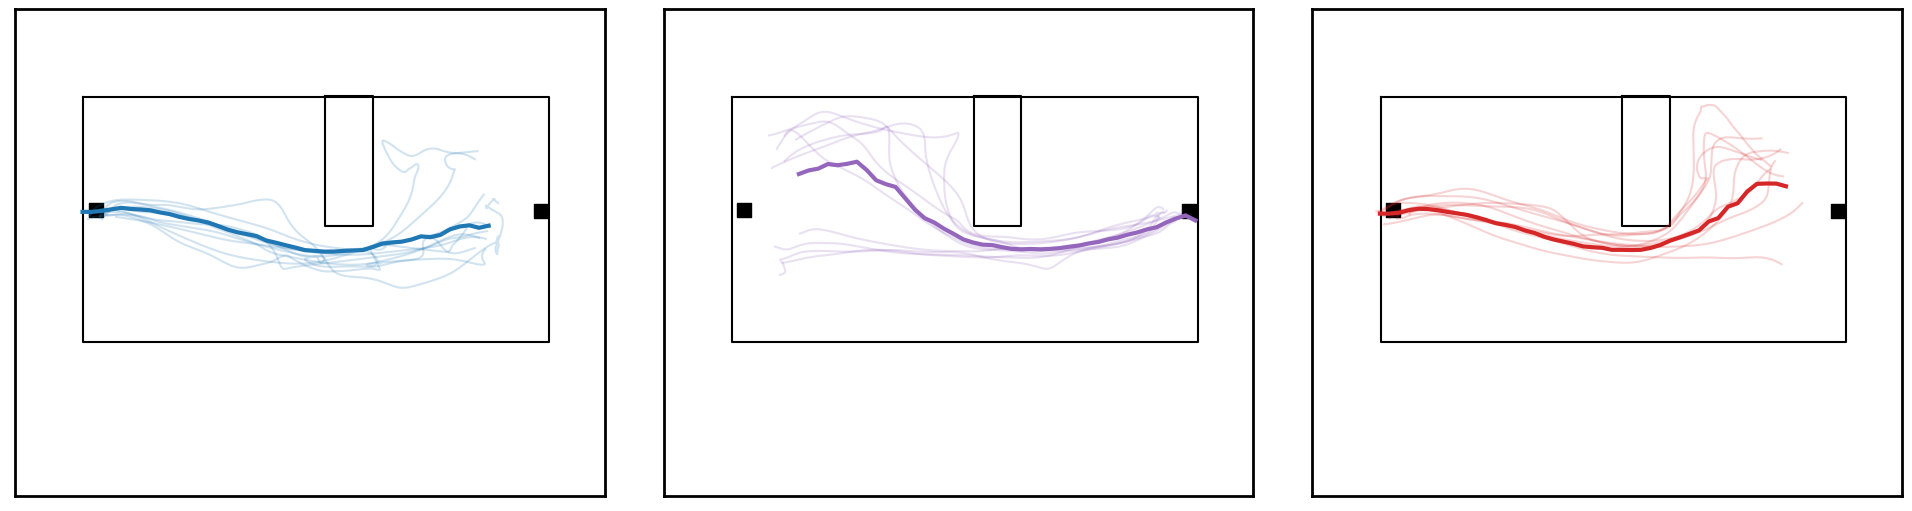

In [184]:
# Create the figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Iterate through each consective_type (0, 1, 2)

 # Filter the data for the current consective_type
light = con_df[(con_df.obstacle_cluster == 1) & 
                 (con_df.task == 'oa') & 
                 (con_df.obstacle_cross == True)  ]
 


# Filter the sample animals
light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
                                                 'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'])]
first = light_sample_towards[light_sample_towards.consective_type == 0]
first_trial = first[first.odd == 'right']

sec = light_sample_towards[light_sample_towards.consective_type == 1]
sec_trial = sec[sec.odd == 'left']


third = light_sample_towards[light_sample_towards.consective_type == 2]
third_trial = third[third.odd == 'right']

first_nose_y,first_nose_x=get_median_trajectory(first_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')

sec_nose_y,sec_nose_x=get_median_trajectory(sec_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')

third_nose_y,third_nose_x=get_median_trajectory(third_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')



plot_arena(light_sample_towards, axes[0])
plot_arena(light_sample_towards, axes[1])
plot_arena(light_sample_towards, axes[2])

axes[0].plot(first_nose_x, first_nose_y, c='tab:blue', linewidth = 3)
axes[1].plot(sec_nose_x, sec_nose_y, c='tab:purple', linewidth = 3)
axes[2].plot(third_nose_x, third_nose_y, c='tab:red', linewidth = 3)

ob_x, ob_y = plot_orginal_obstacle(first_trial, axes[0], 1)
ob_x, ob_y = plot_orginal_obstacle(first_trial, axes[1], 1)
ob_x, ob_y = plot_orginal_obstacle(first_trial, axes[2], 1)

for ind ,row in first_trial.sample(10).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    color = 'tab:blue'
    axes[0].plot(smooth(x), smooth(y), c=color,alpha=.2)

for ind ,row in sec_trial.sample(10).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    color = 'tab:purple'
    axes[1].plot(smooth(x), smooth(y), c=color,alpha=.2)

for ind ,row in third_trial.sample(10).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    color = 'tab:red'
    axes[2].plot(smooth(x), smooth(y), c=color,alpha=.2)

    




for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

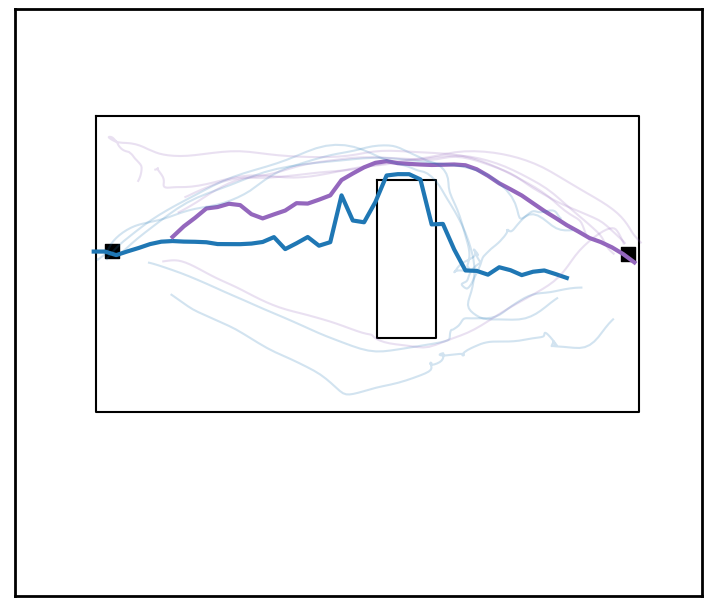

In [160]:
import matplotlib.pyplot as plt

# Create a single subplot
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Filter the relevant data
light = con_df[
    (con_df.obstacle_cluster == 3) &
    (con_df.task == 'oa') &
    (con_df.obstacle_cross == True)
]

# Filter for the sample animals
light_sample_towards = light[light['animal'].isin([
    'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
    'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'
])]

# Select first and second trials
first_trial = light_sample_towards[
    (light_sample_towards.consective_type == 0) &
    (light_sample_towards.odd == 'right')
]

sec_trial = light_sample_towards[
    (light_sample_towards.consective_type == 1) &
    (light_sample_towards.odd == 'left')
]

# Get median trajectories
first_nose_y, first_nose_x = get_median_trajectory(first_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
sec_nose_y, sec_nose_x = get_median_trajectory(sec_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')

# Plot arena and obstacle (just once)
plot_arena(light_sample_towards, ax)
ob_x, ob_y = plot_orginal_obstacle(first_trial, ax, 1)

# Plot median trajectories
ax.plot(first_nose_x, first_nose_y, c='tab:blue', linewidth=3, label='First Trial (Type 0, Right)')
ax.plot(sec_nose_x, sec_nose_y, c='tab:purple', linewidth=3, label='Second Trial (Type 1, Left)')

# Overlay 10 sample smoothed trajectories from each
for _, row in first_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:blue', alpha=0.2)

for _, row in sec_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:purple', alpha=0.2)

# Finalize plot
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

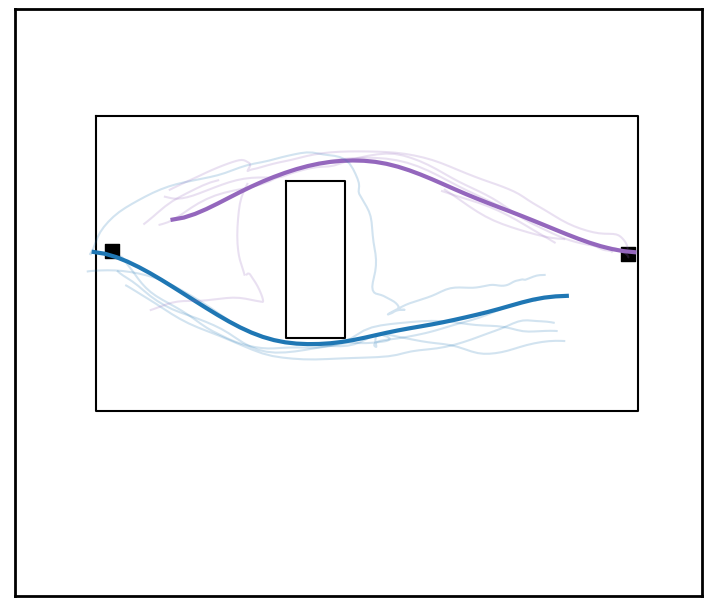

In [ ]:
import matplotlib.pyplot as plt

# Create a single subplot
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Filter the relevant data
light = con_df[
    (con_df.obstacle_cluster == 2) &
    (con_df.task == 'oa') &
    (con_df.obstacle_cross == True)
]

# Filter for the sample animals
light_sample_towards = light[light['animal'].isin([
    'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
    'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'
])]

# Select first and second trials
first_trial = light_sample_towards[
    (light_sample_towards.consective_type == 0) &
    (light_sample_towards.odd == 'right')&(light_sample_towards.start == 'bottom')
]

sec_trial = light_sample_towards[
    (light_sample_towards.consective_type == 1) &
    (light_sample_towards.odd == 'left')
]

# Get median trajectories
first_nose_y, first_nose_x = get_median_trajectory(first_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
sec_nose_y, sec_nose_x = get_median_trajectory(sec_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')

# Plot arena and obstacle (just once)
plot_arena(light_sample_towards, ax)
ob_x, ob_y = plot_orginal_obstacle(first_trial, ax, 1)

# Plot median trajectories
ax.plot(first_nose_x, smooth(first_nose_y,2), c='tab:blue', linewidth=3, label='First Trial (Type 0, Right)')
ax.plot(sec_nose_x, smooth(sec_nose_y,2), c='tab:purple', linewidth=3, label='Second Trial (Type 1, Left)')

# Overlay 10 sample smoothed trajectories from each
for _, row in first_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:blue', alpha=0.2)

for _, row in sec_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:purple', alpha=0.2)

# Finalize plot
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\by_trial_initial_lateral_error.pdf",dpi = 300, transparent=True)


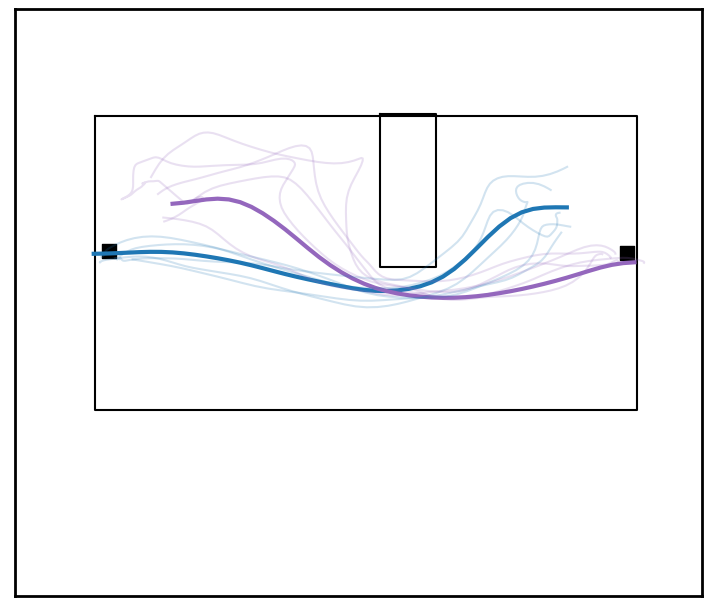

In [175]:
import matplotlib.pyplot as plt

# Create a single subplot
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Filter the relevant data
light = con_df[
    (con_df.obstacle_cluster == 1) &
    (con_df.task == 'oa') &
    (con_df.obstacle_cross == True)
]

# Filter for the sample animals
light_sample_towards = light[light['animal'].isin([
    'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
    'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'
])]

# Select first and second trials
first_trial = light_sample_towards[
    (light_sample_towards.consective_type == 0) &
    (light_sample_towards.odd == 'right')&
    (light_sample_towards.start == 'top')
]

sec_trial = light_sample_towards[
    (light_sample_towards.consective_type == 1) &
    (light_sample_towards.odd == 'left')
]

# Get median trajectories
first_nose_y, first_nose_x = get_median_trajectory(first_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
sec_nose_y, sec_nose_x = get_median_trajectory(sec_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')

# Plot arena and obstacle (just once)
plot_arena(light_sample_towards, ax)
ob_x, ob_y = plot_orginal_obstacle(first_trial, ax, 1)

# Plot median trajectories
ax.plot(first_nose_x, smooth(first_nose_y,2), c='tab:blue', linewidth=3, label='First Trial (Type 0, Right)')
ax.plot(sec_nose_x, smooth(sec_nose_y,2), c='tab:purple', linewidth=3, label='Second Trial (Type 1, Left)')

# Overlay 10 sample smoothed trajectories from each
for _, row in first_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:blue', alpha=0.2)

for _, row in sec_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:purple', alpha=0.2)

# Finalize plot
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()


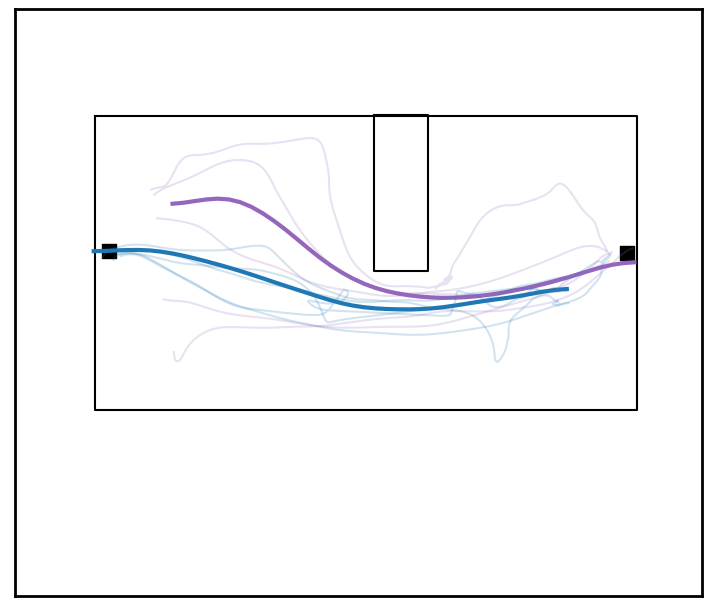

In [176]:
import matplotlib.pyplot as plt

# Create a single subplot
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Filter the relevant data
light = con_df[
    (con_df.obstacle_cluster == 1) &
    (con_df.task == 'oa') &
    (con_df.obstacle_cross == True)
]

# Filter for the sample animals
light_sample_towards = light[light['animal'].isin([
    'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
    'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'
])]

# Select first and second trials
first_trial = light_sample_towards[
    (light_sample_towards.consective_type == 0) &
    (light_sample_towards.odd == 'right')&
    (light_sample_towards.start == 'bottom')
]

sec_trial = light_sample_towards[
    (light_sample_towards.consective_type == 1) &
    (light_sample_towards.odd == 'left')
]

# Get median trajectories
first_nose_y, first_nose_x = get_median_trajectory(first_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
sec_nose_y, sec_nose_x = get_median_trajectory(sec_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')

# Plot arena and obstacle (just once)
plot_arena(light_sample_towards, ax)
ob_x, ob_y = plot_orginal_obstacle(first_trial, ax, 1)

# Plot median trajectories
ax.plot(first_nose_x, smooth(first_nose_y,2), c='tab:blue', linewidth=3, label='First Trial (Type 0, Right)')
ax.plot(sec_nose_x, smooth(sec_nose_y,2), c='tab:purple', linewidth=3, label='Second Trial (Type 1, Left)')

# Overlay 10 sample smoothed trajectories from each
for _, row in first_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:blue', alpha=0.2)

for _, row in sec_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:purple', alpha=0.2)

# Finalize plot
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

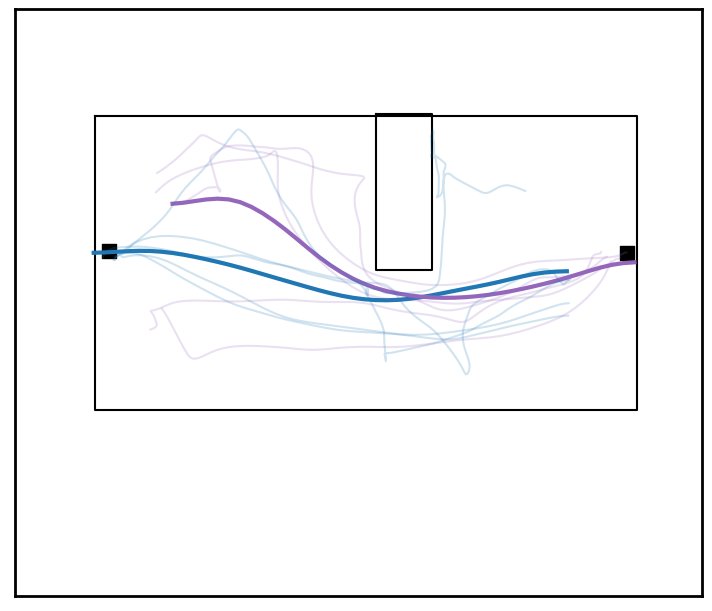

In [179]:
import matplotlib.pyplot as plt

# Create a single subplot
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Filter the relevant data
light = con_df[
    (con_df.obstacle_cluster == 1) &
    (con_df.task == 'oa') &
    (con_df.obstacle_cross == True)
]

# Filter for the sample animals
light_sample_towards = light[light['animal'].isin([
    'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
    'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'
])]

# Select first and second trials
first_trial = light_sample_towards[
    (light_sample_towards.consective_type == 0) &
    (light_sample_towards.odd == 'right')
]

sec_trial = light_sample_towards[
    (light_sample_towards.consective_type == 1) &
    (light_sample_towards.odd == 'left')
]

# Get median trajectories
first_nose_y, first_nose_x = get_median_trajectory(first_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
sec_nose_y, sec_nose_x = get_median_trajectory(sec_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')

# Plot arena and obstacle (just once)
plot_arena(light_sample_towards, ax)
ob_x, ob_y = plot_orginal_obstacle(first_trial, ax, 1)

# Plot median trajectories
ax.plot(first_nose_x, smooth(first_nose_y,2), c='tab:blue', linewidth=3, label='First Trial (Type 0, Right)')
ax.plot(sec_nose_x, smooth(sec_nose_y,2), c='tab:purple', linewidth=3, label='Second Trial (Type 1, Left)')

# Overlay 10 sample smoothed trajectories from each
for _, row in first_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:blue', alpha=0.2)

for _, row in sec_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:purple', alpha=0.2)

# Finalize plot
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

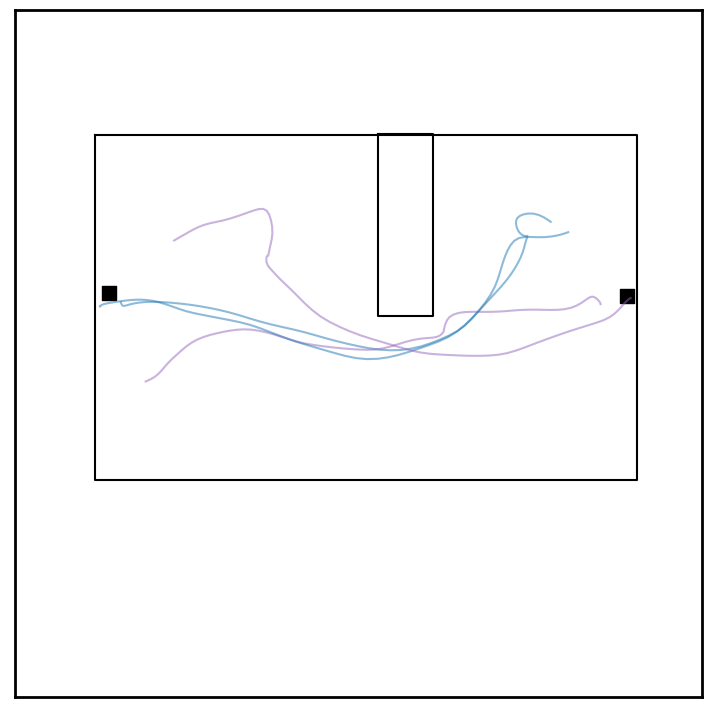

In [141]:
# Create a single subplot figure
fig, ax = plt.subplots(figsize=(8, 8))

# Filter the data for consective_type 0
light = con_df[(con_df.obstacle_cluster == 1) & 
               (con_df.task == 'oa') & 
               (con_df.obstacle_cross == True)]
light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
                                                 'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'])]
first_trials = light_sample_towards[light_sample_towards.consective_type == 0]

# Plot arena and obstacle
plot_arena(light_sample_towards, ax)
ob_x, ob_y = plot_orginal_obstacle(first_trials, ax, 1)

# Sample 20 type 0 trials and plot their consecutive sequences
for ind, row in first_trials.sample(2).iterrows():
    # Get consecutive trials (types 1 and 2)
    try:
        type1_trial = con_df.loc[ind + 1] if (ind + 1) in con_df.index else None
        type2_trial = con_df.loc[ind + 2] if (ind + 2) in con_df.index else None
    except KeyError:
        continue
    
    # Plot type 0 trial (blue)
    x0, y0 = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x0), smooth(y0), c='tab:blue', alpha=.5
    )
    
    # Plot type 1 trial (purple) if exists
    if type1_trial is not None and type1_trial['consective_type'] == 1:
        x1, y1 = correct_trace(type1_trial, ob_x, ob_y)
        ax.plot(smooth(x1), smooth(y1), c='tab:purple', alpha=.5
        )
    
    # Plot type 2 trial (red) if exists
    #if type2_trial is not None and type2_trial['consective_type'] == 2:
   #     x2, y2 = correct_trace(type2_trial, ob_x, ob_y)
       # ax.plot(smooth(x2), smooth(y2), c='tab:red', alpha=1
    #    )





# Formatting
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

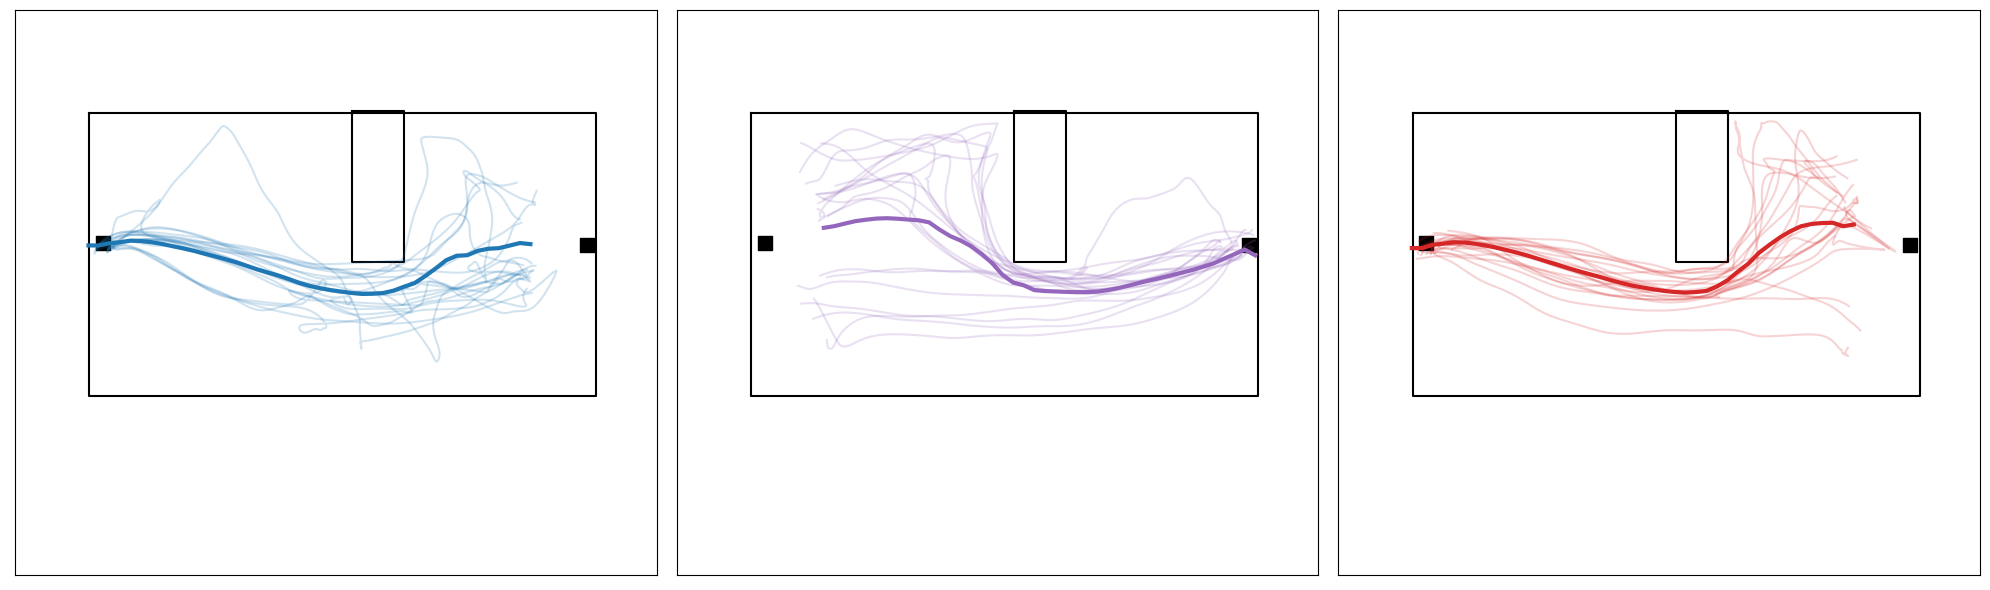

In [10]:
# Create the figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Iterate through each consective_type (0, 1, 2)

 # Filter the data for the current consective_type
light = con_df[(con_df.obstacle_cluster == 1) & 
                 (con_df.task == 'oa') & 
                 (con_df.obstacle_cross == True)  ]
 


# Filter the sample animals
light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
                                                 'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'])]
first = light_sample_towards[light_sample_towards.consective_type == 0]
first_trial = first[first.odd == 'right']

sec = light_sample_towards[light_sample_towards.consective_type == 1]
sec_trial = sec[sec.odd == 'left']


third = light_sample_towards[light_sample_towards.consective_type == 2]
third_trial = third[third.odd == 'right']

first_nose_y,first_nose_x=get_median_trajectory(first_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')

sec_nose_y,sec_nose_x=get_median_trajectory(sec_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')

third_nose_y,third_nose_x=get_median_trajectory(third_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')



plot_arena(light_sample_towards, axes[0])
plot_arena(light_sample_towards, axes[1])
plot_arena(light_sample_towards, axes[2])

axes[0].plot(first_nose_x, first_nose_y, c='tab:blue', linewidth = 3)
axes[1].plot(sec_nose_x, sec_nose_y, c='tab:purple', linewidth = 3)
axes[2].plot(third_nose_x, third_nose_y, c='tab:red', linewidth = 3)

ob_x, ob_y = plot_orginal_obstacle(first_trial, axes[0], 1)
ob_x, ob_y = plot_orginal_obstacle(first_trial, axes[1], 1)
ob_x, ob_y = plot_orginal_obstacle(first_trial, axes[2], 1)

for ind ,row in first_trial.sample(20).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    color = 'tab:blue'
    axes[0].plot(smooth(x), smooth(y), c=color,alpha=.2)

for ind ,row in sec_trial.sample(20).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    color = 'tab:purple'
    axes[1].plot(smooth(x), smooth(y), c=color,alpha=.2)

for ind ,row in third_trial.sample(20).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    color = 'tab:red'
    axes[2].plot(smooth(x), smooth(y), c=color,alpha=.2)

    




for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()


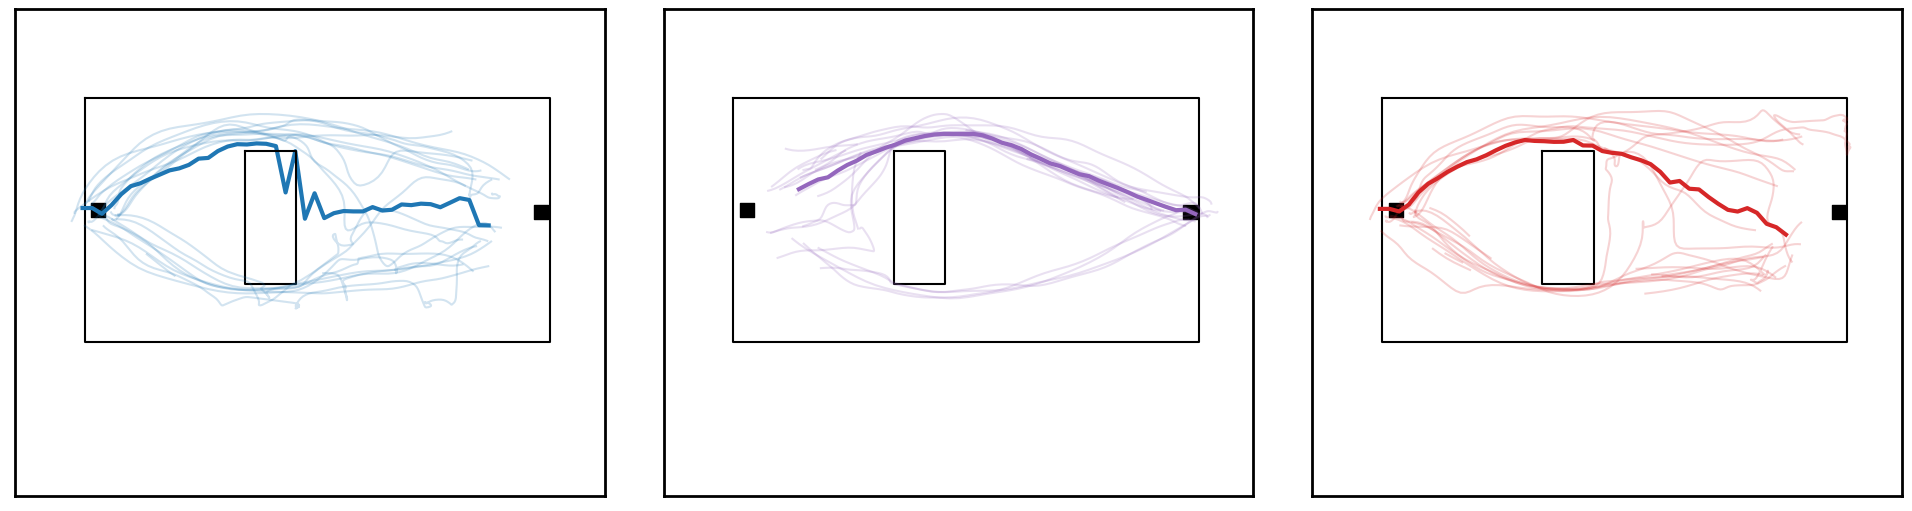

In [164]:
# Create the figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Iterate through each consective_type (0, 1, 2)

 # Filter the data for the current consective_type
light = con_df[(con_df.obstacle_cluster == 2) & 
                 (con_df.task == 'oa') & 
                 (con_df.obstacle_cross == True)  ]
 


# Filter the sample animals
light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
                                                 'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'])]
first = light_sample_towards[light_sample_towards.consective_type == 0]
first_trial = first[first.odd == 'right']

sec = light_sample_towards[light_sample_towards.consective_type == 1]
sec_trial = sec[sec.odd == 'left']


third = light_sample_towards[light_sample_towards.consective_type == 2]
third_trial = third[third.odd == 'right']

first_nose_y,first_nose_x=get_median_trajectory(first_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')

sec_nose_y,sec_nose_x=get_median_trajectory(sec_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')

third_nose_y,third_nose_x=get_median_trajectory(third_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')



plot_arena(light_sample_towards, axes[0])
plot_arena(light_sample_towards, axes[1])
plot_arena(light_sample_towards, axes[2])

axes[0].plot(first_nose_x, first_nose_y, c='tab:blue', linewidth = 3)
axes[1].plot(sec_nose_x, sec_nose_y, c='tab:purple', linewidth = 3)
axes[2].plot(third_nose_x, third_nose_y, c='tab:red', linewidth = 3)

ob_x, ob_y = plot_orginal_obstacle(first_trial, axes[0], 1)
ob_x, ob_y = plot_orginal_obstacle(first_trial, axes[1], 1)
ob_x, ob_y = plot_orginal_obstacle(first_trial, axes[2], 1)

for ind ,row in first_trial.sample(20).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    color = 'tab:blue'
    axes[0].plot(smooth(x), smooth(y), c=color,alpha=.2)

for ind ,row in sec_trial.sample(20).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    color = 'tab:purple'
    axes[1].plot(smooth(x), smooth(y), c=color,alpha=.2)

for ind ,row in third_trial.sample(20).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    color = 'tab:red'
    axes[2].plot(smooth(x), smooth(y), c=color,alpha=.2)

    




for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

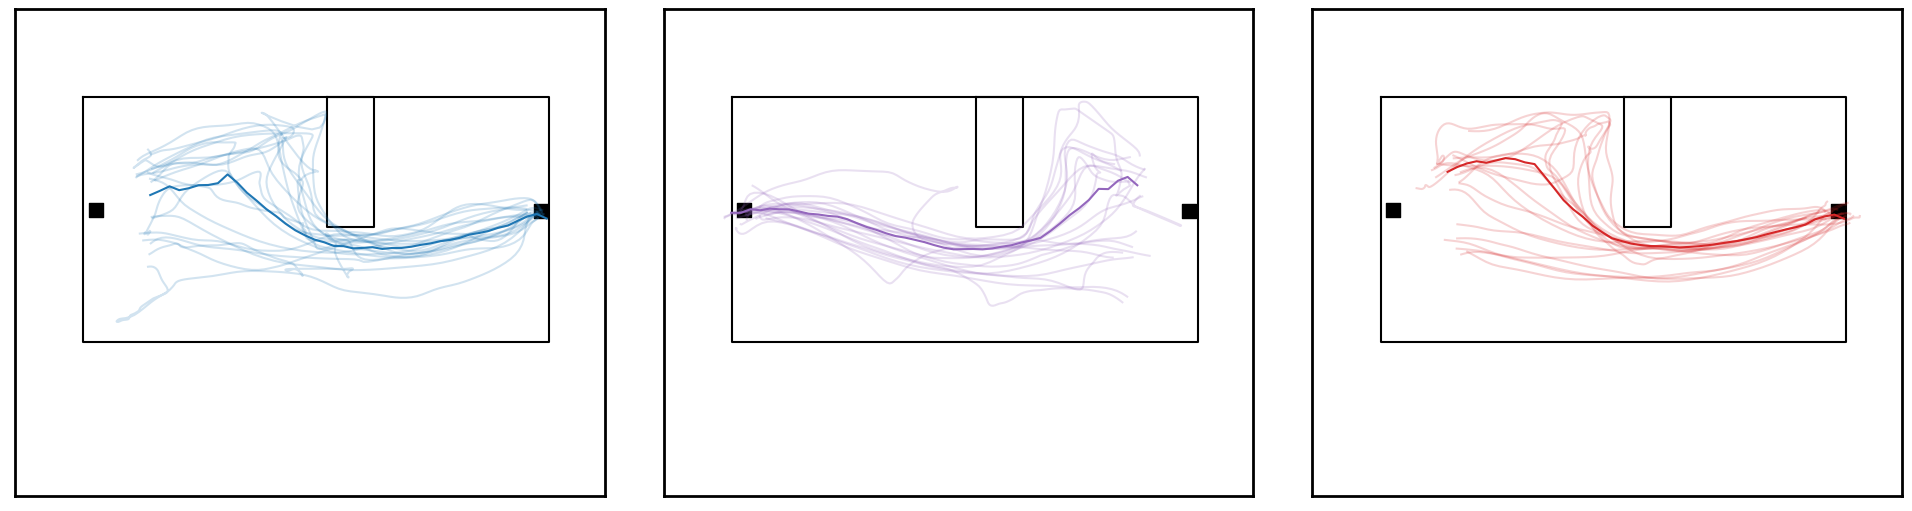

In [163]:
# Create the figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Iterate through each consective_type (0, 1, 2)

 # Filter the data for the current consective_type
light = con_df[(con_df.obstacle_cluster == 1) & 
                 (con_df.task == 'oa') & 
                 (con_df.obstacle_cross == True)  ]
 


# Filter the sample animals
light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
                                                 'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'])]
first = light_sample_towards[light_sample_towards.consective_type == 0]
first_trial = first[first.odd == 'left']

sec = light_sample_towards[light_sample_towards.consective_type == 1]
sec_trial = sec[sec.odd == 'right']


third = light_sample_towards[light_sample_towards.consective_type == 2]
third_trial = third[third.odd == 'left']

first_nose_y,first_nose_x=get_median_trajectory(first_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')

sec_nose_y,sec_nose_x=get_median_trajectory(sec_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')

third_nose_y,third_nose_x=get_median_trajectory(third_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')



plot_arena(light_sample_towards, axes[0])
plot_arena(light_sample_towards, axes[1])
plot_arena(light_sample_towards, axes[2])

axes[0].plot(first_nose_x, first_nose_y, c='tab:blue')
axes[1].plot(sec_nose_x, sec_nose_y, c='tab:purple')
axes[2].plot(third_nose_x, third_nose_y, c='tab:red')

ob_x, ob_y = plot_orginal_obstacle(first_trial, axes[0], 1)
ob_x, ob_y = plot_orginal_obstacle(first_trial, axes[1], 1)
ob_x, ob_y = plot_orginal_obstacle(first_trial, axes[2], 1)

for ind ,row in first_trial.sample(20).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    color = 'tab:blue'
    axes[0].plot(smooth(x), smooth(y), c=color,alpha=.2)

for ind ,row in sec_trial.sample(20).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    color = 'tab:purple'
    axes[1].plot(smooth(x), smooth(y), c=color,alpha=.2)

for ind ,row in third_trial.sample(20).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    color = 'tab:red'
    axes[2].plot(smooth(x), smooth(y), c=color,alpha=.2)

    




for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()


In [2]:
def goal_port(df):
    for ind,row in df.iterrows():
        ob_ind = int(row.obstacle_ind)
        df.at[ind,'goal_distance_from_target_port'] = row.ts_distance_from_target_port[ob_ind:].astype(object)
        df.at[ind,'goal_angle_to_target_port'] = row.ts_angle_to_target_port[ob_ind:].astype(object)
        df.at[ind,'goal_lateral_error_to_target_port'] = row.ts_lateral_error_to_target_port[ob_ind:].astype(object)

In [ ]:
import pandas as pd
import os

def split_and_save_dataframe(df, split_ratio, output_dir, filename_prefix):
    """
    Split a DataFrame and save parts as H5 files.
    
    Parameters:
    - df: pandas DataFrame to split
    - split_ratio: fraction of data to go to first file (0.0 to 1.0)
    - output_dir: directory to save files
    - filename_prefix: prefix for output filenames
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Split the DataFrame
    split_index = int(len(df) * split_ratio)
    df1 = df.iloc[:split_index]
    df2 = df.iloc[split_index:]
    
    # Create filenames
    file1 = os.path.join(output_dir, f"{filename_prefix}_part1.h5")
    file2 = os.path.join(output_dir, f"{filename_prefix}_part2.h5")
    
    # Save to HDF5 format
    df1.to_hdf(file1, key='data', mode='w')
    df2.to_hdf(file2, key='data', mode='w')
    
    print(f"Data saved to:\n- {file1}\n- {file2}")

# Example usage:
# df = pd.read_csv('your_large_file.csv')  # or however you load your data
# split_and_save_dataframe(df, 0.5, '/path/to/output/directory', 'my_data')

In [835]:
turn_to_obstacle(joint)

new2


In [92]:
intial_lateral_error(con_df)

In [836]:
split_and_save_dataframe(joint,.5,r'\\goeppert\Vol2\mike\metadata\behavior_paper_data','light_dark')

Data saved to:
- \\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part1.h5
- \\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part2.h5


In [18]:
light.odd

7        left
37       left
43       left
64      right
65       left
        ...  
8798     left
8840     left
8857     left
8863     left
8880     left
Name: odd, Length: 471, dtype: object

In [5]:
light_dark_1 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part1.h5")
light_dark_2 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part2.h5")
light_dark = pd.concat([light_dark_1,light_dark_2])

In [7]:
con_df = create_consective_df_new(light_dark)

In [76]:
intial_lateral_error(light_dark)

In [77]:
intial_lateral_error(con_df)

In [330]:
long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(light_dark)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(light_dark)

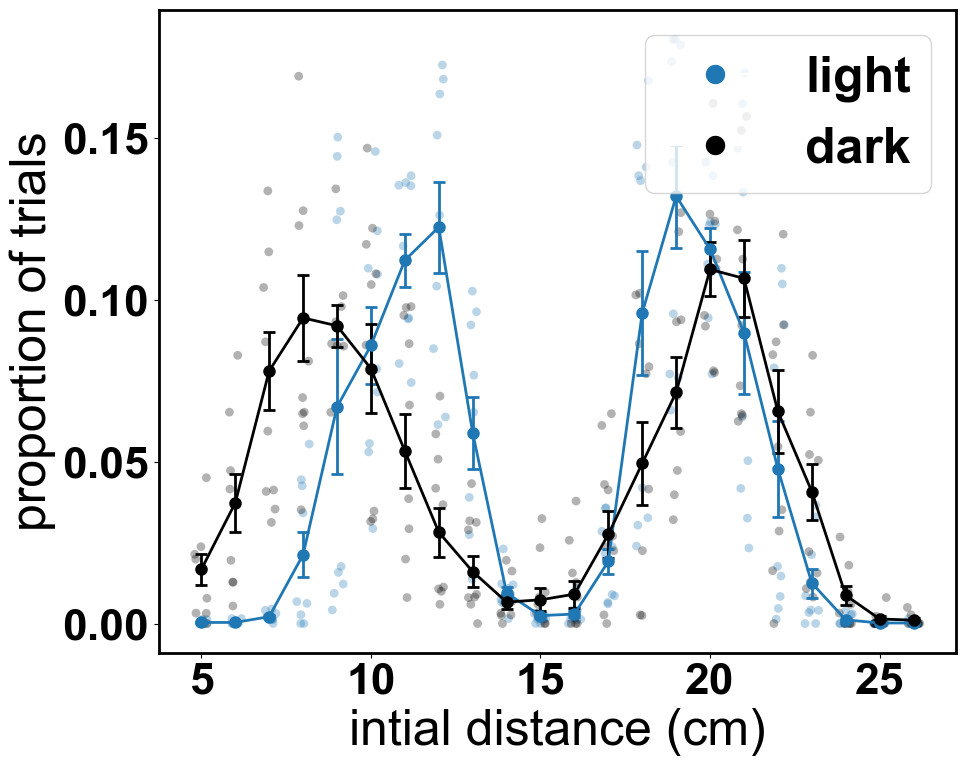

In [178]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(5, 27, 1)
data = pd.concat([light_dark])
data = data[data['animal'].isin(['G8CK1RT', 'G8CK1LT',
       'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
       'G8CKLN'])]
data = drop_nans_in_columns(data,'intial_distance')
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.intial_distance.to_numpy())
light_dist = light_dist[np.where((light_dist >= 5))]
light_dist = light_dist[np.where((light_dist <= 27))]

light_counts, light_bins = np.histogram(light_dist, bins=22,range=(5,27))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.intial_distance.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 5))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 27))]
  
    counts, light_bins = np.histogram(ani_light_dists, bins=22,range=(5,27))
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.intial_distance.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 5))]
dark_dist = dark_dist[np.where((dark_dist <= 27))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=22,range=(5,27))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.intial_distance.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 5))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 27))]
   
    counts, dark_bins = np.histogram(ani_dark_dists, bins=22,range=(5,27))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)/ np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting



ax.set_ylabel('proportion of trials', fontsize=36)  # lowercase
ax.set_xlabel('intial distance (cm)', fontsize=36)  # lowercase
# Formatting

#ax.set_xticks([0, -5,0, 5,10])



# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=36, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper right', fontsize=36, framealpha=0.8)

plt.tight_layout()

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


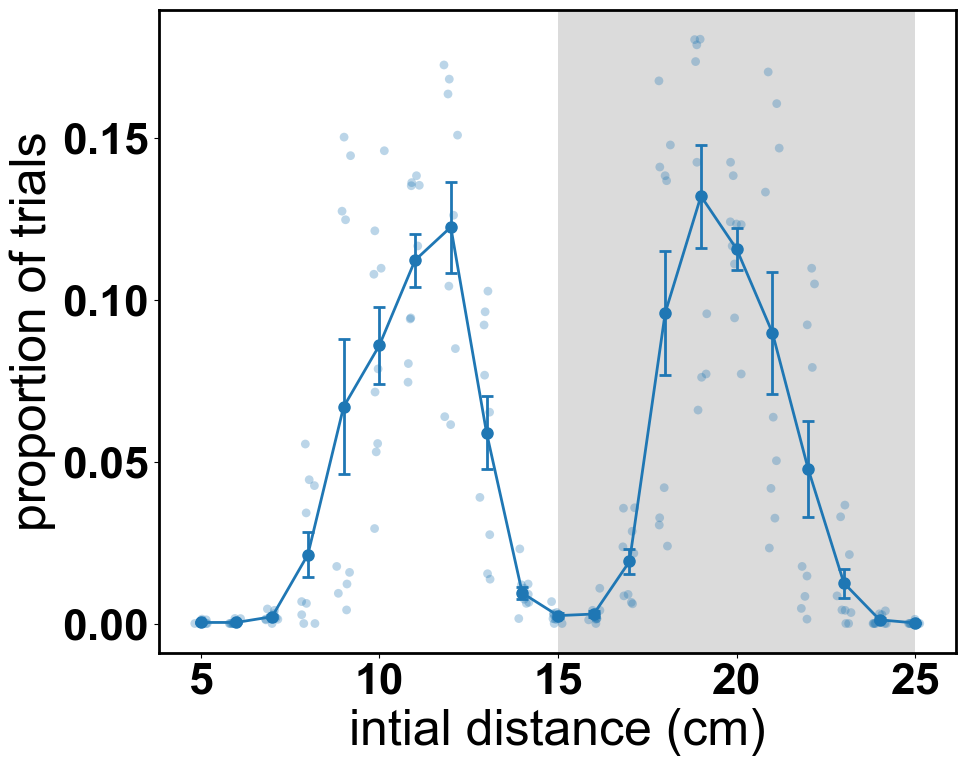

In [201]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(5, 26, 1)
data = pd.concat([light_dark])
data = data[data['animal'].isin(['G8CK1RT', 'G8CK1LT',
       'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
       'G8CKLN'])]
data = drop_nans_in_columns(data,'intial_distance')
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.intial_distance.to_numpy())
light_dist = light_dist[np.where((light_dist >= 5))]
light_dist = light_dist[np.where((light_dist <= 25))]

light_counts, light_bins = np.histogram(light_dist, bins=21)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.intial_distance.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 5))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 25))]
  
    counts, light_bins = np.histogram(ani_light_dists, bins=21,range=(5,25))
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

ax.axvspan(15, 25, facecolor='lightgrey', alpha=.8)
# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')


# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')


# Formatting



ax.set_ylabel('proportion of trials', fontsize=36)  # lowercase
ax.set_xlabel('intial distance (cm)', fontsize=36)  # lowercase
# Formatting
# Add shaded region from -13 to 0
 # light grey shading with some transparency
#ax.set_xticks([0, -5,0, 5,10])



# Add grid lines



# Legend with matching style
# Update your legend call



plt.tight_layout()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_figures\initial_distance_error.pdf",dpi = 300, transparent=True)

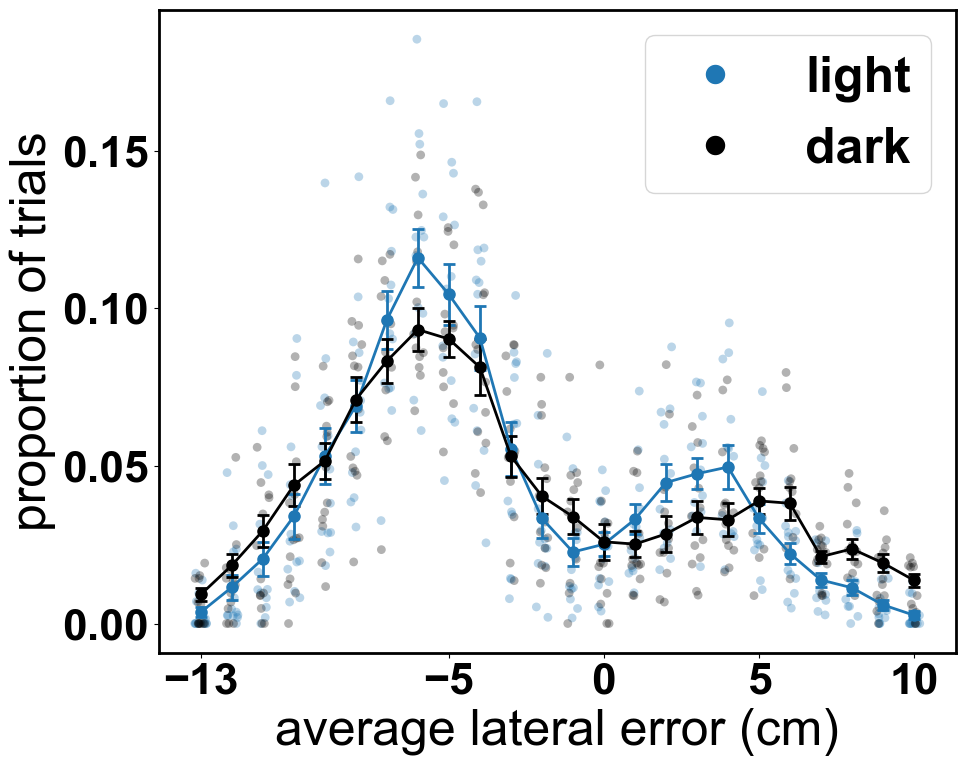

In [96]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(-13, 11, 1)
data = pd.concat([light_dark])
data = data[~data['obstacle_cluster'].isin([2,3])]
data = drop_nans_in_columns(data,'intial_lateral_error')
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.intial_lateral_error.to_numpy())
light_dist = light_dist[np.where((light_dist >= -13))]

light_counts, light_bins = np.histogram(light_dist, bins=24,range=(-13,11))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.intial_lateral_error.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= -13))]
  
    counts, bins = np.histogram(ani_light_dists, bins=24,range=(-13,11))
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.intial_lateral_error.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= -13))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=24,range=(-13,11))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.intial_lateral_error.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= -13))]
   
    counts, bins = np.histogram(ani_dark_dists, bins=24,range=(-13,11))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)/ np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting



ax.set_ylabel('proportion of trials', fontsize=36)  # lowercase
ax.set_xlabel('average lateral error (cm)', fontsize=36)  # lowercase
# Formatting

ax.set_xticks([-13, -5,0, 5,10])



# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=36, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper right', fontsize=36, framealpha=0.8)

plt.tight_layout()

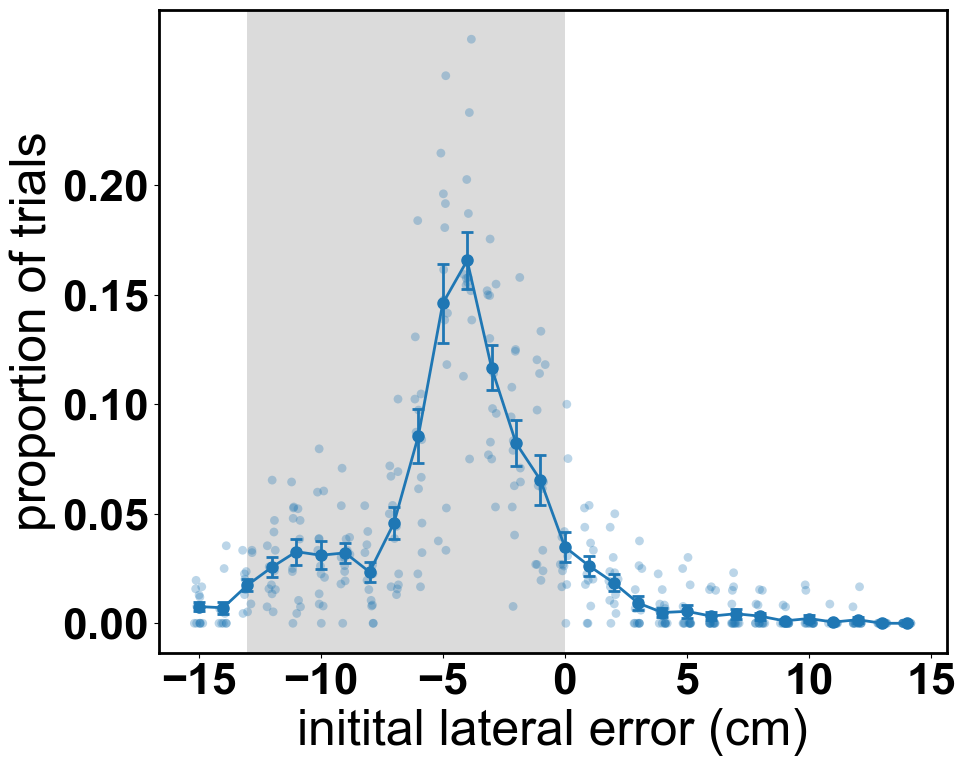

In [9]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(-15, 15, 1)
data = pd.concat([light_dark])
data = data[data['obstacle_cluster'].isin([2,3])]
data = drop_nans_in_columns(data,'intial_lateral_error')
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.intial_lateral_error.to_numpy())


light_counts, light_bins = np.histogram(light_dist, bins=len(xnew),range=(-15,15))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.intial_lateral_error.to_numpy())
    
  
    counts, bins = np.histogram(ani_light_dists, bins=len(xnew),range=(-15,15))
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Add shaded region from -13 to 0
ax.axvspan(-13, 0, facecolor='lightgrey', alpha=.8)  # light grey shading with some transparency

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

# Formatting
ax.set_ylabel('proportion of trials', fontsize=36)  # lowercase
ax.set_xlabel('initital lateral error (cm)', fontsize=36)  # lowercase
ax.set_xticks([-15,-10, -5, 0, 5, 10,15])
ax.set_yticks([0.  , 0.05, 0.1 , 0.15,.2])

plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\intial_lateral_error.pdf",dpi = 300, transparent=True)



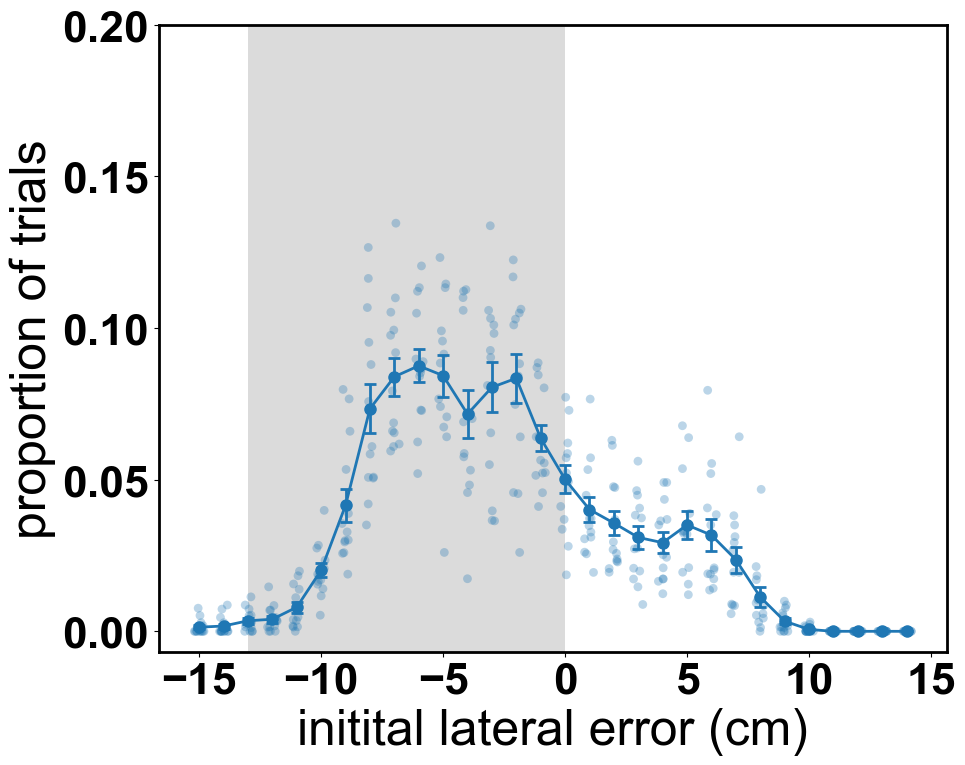

In [14]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(-15, 15, 1)
data = pd.concat([light_dark])
#data = data[~data['obstacle_cluster'].isin([2,3])]
data = drop_nans_in_columns(data,'avg_lateral_error')
#data = data[data.intial_distance<=15] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.avg_lateral_error.to_numpy())


light_counts, light_bins = np.histogram(light_dist, bins=len(xnew),range=(-15,15))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.avg_lateral_error.to_numpy())
    
  
    counts, bins = np.histogram(ani_light_dists, bins=len(xnew),range=(-15,15))
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Add shaded region from -13 to 0
ax.axvspan(-13, 0, facecolor='lightgrey', alpha=.8)  # light grey shading with some transparency

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

# Formatting
ax.set_ylabel('proportion of trials', fontsize=36)  # lowercase
ax.set_xlabel('initital lateral error (cm)', fontsize=36)  # lowercase
ax.set_xticks([-15,-10, -5, 0, 5, 10,15])
ax.set_yticks([0.  , 0.05, 0.1 , 0.15,.2])

plt.tight_layout()

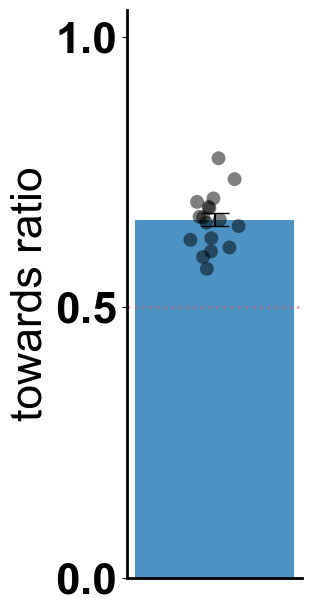

In [17]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(4, 7))  # Narrower figure for single bar

# Prepare data - using light_dark dataframe and filtering for light condition
light_data = light_dark[light_dark['task'] == 'oa']
light_data = light_dark[~light_dark['obstacle_cluster'].isin([2,3])]
#data = data[data.intial_distance<=15] 

# Group level calculation
total = len(light_data)
towards = len(light_data[light_data['turn_to_obstacle'] == 'towards']) if total > 0 else 0
ratio = towards / total if total > 0 else 0

# Individual animal calculation
animal_ratios = []
for animal in light_data['animal'].unique():
    animal_data = light_data[light_data['animal'] == animal]
    a_total = len(animal_data)
    a_towards = len(animal_data[animal_data['turn_to_obstacle'] == 'towards']) if a_total > 0 else 0
    a_ratio = a_towards / a_total if a_total > 0 else 0
    animal_ratios.append(a_ratio)

# Calculate standard error
se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0

# Plot settings
bar_width = 0.6
color = 'tab:blue'
x_pos = 0  # Single bar position

# Plot 50% reference line
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bar with error bar
ax.bar(x_pos, ratio, bar_width,
       color=color,
       edgecolor='none',
       alpha=0.8,
       yerr=se,
       capsize=10)  # Larger cap size for single bar

# Plot individual data points with jitter
jitter = np.random.normal(0, 0.05, size=len(animal_ratios))  # Slightly wider jitter
ax.scatter(x_pos + jitter, animal_ratios,
           color='black', alpha=0.5, s=100, edgecolor='none')  # Larger points

# Customize plot
ax.set_ylabel('towards ratio')
ax.set_xticks([])  # Remove x-axis ticks since we only have one bar
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove grid and frame elements
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\towards_ratio_light_bar.pdf",dpi = 300, transparent=True)
plt.show()

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


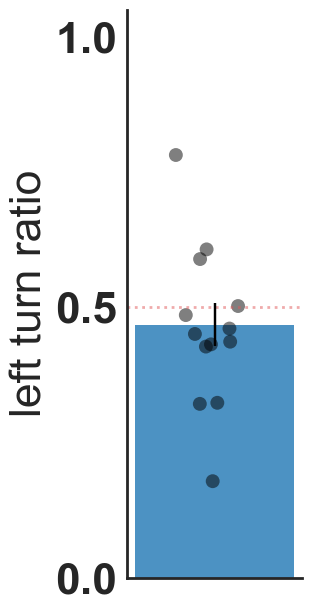

In [922]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(4, 7))

# Prepare data - using light_dark dataframe and filtering for light condition
light_data = light_dark[light_dark['task'] == 'oa']

# Group level calculation
total = len(light_data)
left = len(light_data[light_data['turn_direction_left_right'] == 'left']) if total > 0 else 0
ratio = left / total if total > 0 else 0

# Individual animal calculation
animal_ratios = []
for animal in light_data['animal'].unique():
    animal_data = light_data[light_data['animal'] == animal]
    a_total = len(animal_data)
    a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
    a_ratio = a_left / a_total if a_total > 0 else 0
    animal_ratios.append(a_ratio)

# Calculate standard error
se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0

# Plot settings
bar_width = 0.6
color = 'tab:blue' 
x_pos = 0  # Single bar position

# Plot 50% reference line (chance level for left/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bar with error bar
ax.bar(x_pos, ratio, bar_width,
       color=color,
       edgecolor='none',
       alpha=0.8,
       yerr=se,
       capsize=10)

# Plot individual data points with jitter
jitter = np.random.normal(0, 0.05, size=len(animal_ratios))
ax.scatter(x_pos + jitter, animal_ratios,
           color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('left turn ratio')
ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\left_ratio_light_bar.pdf",dpi = 300, transparent=True)
plt.show()

In [ ]:
light_data = light_dark[light_dark['task'] == 'oadark']
light_data = light_dark[light_dark['obstacle_cluster'].isin([2,3])]


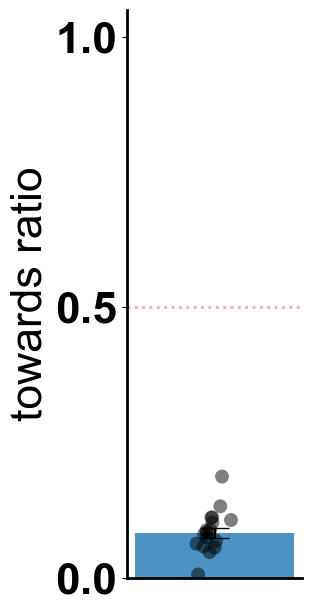

In [19]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(4, 7))  # Narrower figure for single bar

# Prepare data - using light_dark dataframe and filtering for light condition
light_data = light_dark[light_dark['task'] == 'oa']
light_data = light_dark[light_dark['obstacle_cluster'].isin([2,3])]

# Group level calculation
total = len(light_data)
towards = len(light_data[light_data['turn_to_obstacle'] == 'towards']) if total > 0 else 0
ratio = towards / total if total > 0 else 0

# Individual animal calculation
animal_ratios = []
for animal in light_data['animal'].unique():
    animal_data = light_data[light_data['animal'] == animal]
    a_total = len(animal_data)
    a_towards = len(animal_data[animal_data['turn_to_obstacle'] == 'towards']) if a_total > 0 else 0
    a_ratio = a_towards / a_total if a_total > 0 else 0
    animal_ratios.append(a_ratio)

# Calculate standard error
se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0

# Plot settings
bar_width = 0.6
color = 'tab:blue'
x_pos = 0  # Single bar position

# Plot 50% reference line
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bar with error bar
ax.bar(x_pos, ratio, bar_width,
       color=color,
       edgecolor='none',
       alpha=0.8,
       yerr=se,
       capsize=10)  # Larger cap size for single bar

# Plot individual data points with jitter
jitter = np.random.normal(0, 0.05, size=len(animal_ratios))  # Slightly wider jitter
ax.scatter(x_pos + jitter, animal_ratios,
           color='black', alpha=0.5, s=100, edgecolor='none')  # Larger points

# Customize plot
ax.set_ylabel('towards ratio')
ax.set_xticks([])  # Remove x-axis ticks since we only have one bar
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove grid and frame elements
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()

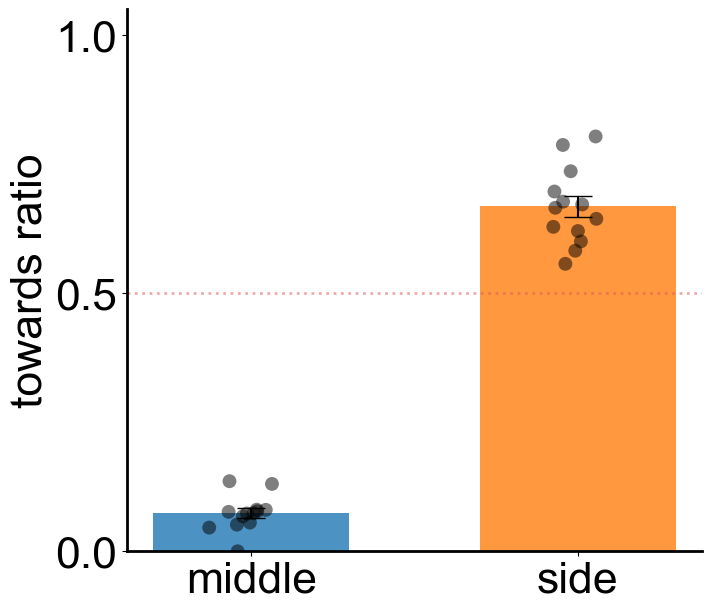

In [25]:
font = {'family': 'arial', 'size': 36,'weight':'normal'}
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(8, 7))  # Wider figure for two bars

# Prepare data - using light_dark dataframe and filtering for light condition
light_data = light_dark[light_dark['task'] == 'oa']

# Filter for middle and side clusters
middle_data = light_data[light_data['obstacle_cluster'].isin([2, 3])]
side_data = light_data[light_data['obstacle_cluster'].isin([1, 4])]

# Function to calculate ratio and individual animal ratios
def calculate_ratios(data):
    total = len(data)
    towards = len(data[data['turn_to_obstacle'] == 'towards']) if total > 0 else 0
    ratio = towards / total if total > 0 else 0
    
    animal_ratios = []
    for animal in data['animal'].unique():
        animal_data = data[data['animal'] == animal]
        a_total = len(animal_data)
        a_towards = len(animal_data[animal_data['turn_to_obstacle'] == 'towards']) if a_total > 0 else 0
        a_ratio = a_towards / a_total if a_total > 0 else 0
        animal_ratios.append(a_ratio)
    
    se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
    return ratio, animal_ratios, se

# Calculate for middle and side
middle_ratio, middle_animal_ratios, middle_se = calculate_ratios(middle_data)
side_ratio, side_animal_ratios, side_se = calculate_ratios(side_data)

# Plot settings
bar_width = 0.6
colors = ['tab:blue', 'tab:orange']  # Different colors for middle and side
x_positions = [0, 1]  # Positions for the two bars
labels = ['middle', 'side']

# Plot 50% reference line
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bars with error bars
for i, (ratio, se, color, label) in enumerate(zip([middle_ratio, side_ratio], 
                                                 [middle_se, side_se], 
                                                 colors, labels)):
    ax.bar(x_positions[i], ratio, bar_width,
           color=color,
           edgecolor='none',
           alpha=0.8,
           yerr=se,
           capsize=10,
           label=label)

# Plot individual data points with jitter
for i, animal_ratios in enumerate([middle_animal_ratios, side_animal_ratios]):
    jitter = np.random.normal(0, 0.05, size=len(animal_ratios))
    ax.scatter(x_positions[i] + jitter, animal_ratios,
               color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('towards ratio')
ax.set_xticks(x_positions)
ax.set_xticklabels(labels)
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)

# Add legend


# Remove grid and frame elements
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

<AxesSubplot: >

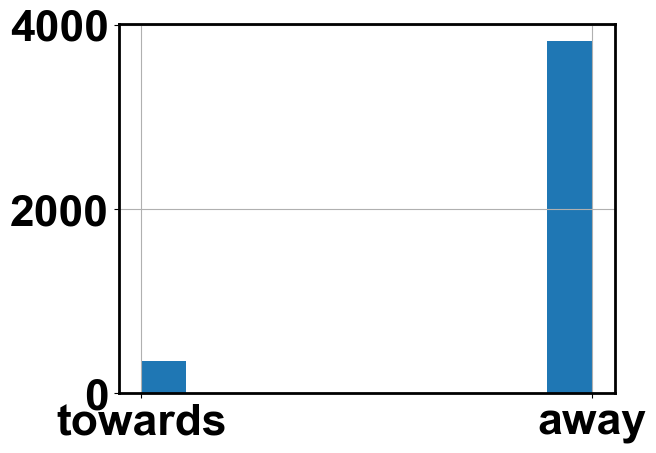

In [21]:
light_data.turn_to_obstacle.hist()

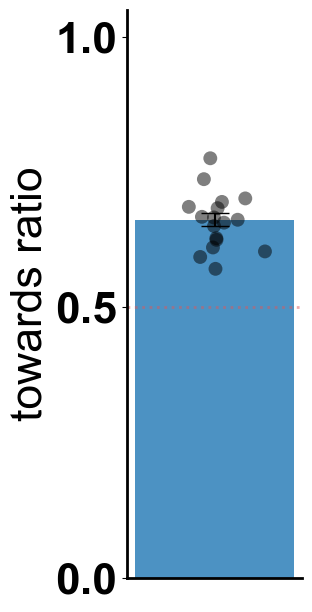

In [18]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(4, 7))  # Narrower figure for single bar

# Prepare data - using light_dark dataframe and filtering for light condition
light_data = light_dark[light_dark['task'] == 'oa']
light_data = light_dark[~light_dark['obstacle_cluster'].isin([2,3])]

# Group level calculation
total = len(light_data)
towards = len(light_data[light_data['turn_to_obstacle'] == 'towards']) if total > 0 else 0
ratio = towards / total if total > 0 else 0

# Individual animal calculation
animal_ratios = []
for animal in light_data['animal'].unique():
    animal_data = light_data[light_data['animal'] == animal]
    a_total = len(animal_data)
    a_towards = len(animal_data[animal_data['turn_to_obstacle'] == 'towards']) if a_total > 0 else 0
    a_ratio = a_towards / a_total if a_total > 0 else 0
    animal_ratios.append(a_ratio)

# Calculate standard error
se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0

# Plot settings
bar_width = 0.6
color = 'tab:blue'
x_pos = 0  # Single bar position

# Plot 50% reference line
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bar with error bar
ax.bar(x_pos, ratio, bar_width,
       color=color,
       edgecolor='none',
       alpha=0.8,
       yerr=se,
       capsize=10)  # Larger cap size for single bar

# Plot individual data points with jitter
jitter = np.random.normal(0, 0.05, size=len(animal_ratios))  # Slightly wider jitter
ax.scatter(x_pos + jitter, animal_ratios,
           color='black', alpha=0.5, s=100, edgecolor='none')  # Larger points

# Customize plot
ax.set_ylabel('towards ratio')
ax.set_xticks([])  # Remove x-axis ticks since we only have one bar
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove grid and frame elements
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()

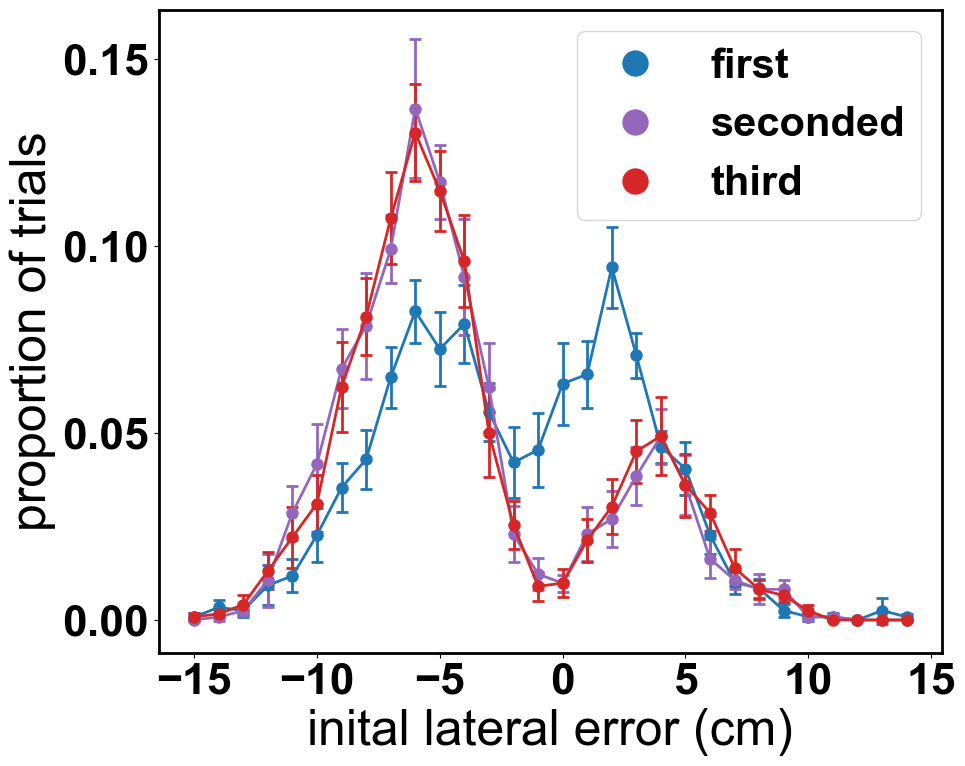

In [9]:
plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

xnew = np.arange(-15, 15, 1)
data = con_df[~con_df['obstacle_cluster'].isin([2,3])]
data = data[data.task == 'oa']
data = drop_nans_in_columns(data, 'intial_lateral_error')


fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process consecutive_type 0 (first)
first = data[data.consective_type == 0]
first_dist = first.intial_lateral_error.to_numpy()
first_dist = first_dist[np.where((first_dist >= -15))]

first_counts, first_bins = np.histogram(first_dist, bins=len(xnew), range=(-15,15))
first_hist = (first_counts / sum(first_counts))

# Process consecutive_type 1 (seconded)
second = data[data.consective_type == 1]
second_dist = second.intial_lateral_error.to_numpy()
second_dist = second_dist[np.where((second_dist >= -15))]

second_counts, second_bins = np.histogram(second_dist, bins=len(xnew), range=(-15,15))
second_hist = (second_counts / sum(second_counts))

# Process consecutive_type 2 (third)
third = data[data.consective_type == 2]
third_dist = third.intial_lateral_error.to_numpy()
third_dist = third_dist[np.where((third_dist >= -15))]

third_counts, third_bins = np.histogram(third_dist, bins=len(xnew), range=(-15,15))
third_hist = (third_counts / sum(third_counts))

# Calculate standard errors
first_prob = []
second_prob = []
third_prob = []

for ani, ani_df in first.groupby(['animal']):
    ani_first_dists = ani_df.intial_lateral_error.to_numpy()
    ani_first_dists = ani_first_dists[np.where((ani_first_dists >= -15))]
    counts, bins = np.histogram(ani_first_dists, bins=len(xnew), range=(-15,15))
    prob = counts / sum(counts)
    first_prob.append(prob)

for ani, ani_df in second.groupby(['animal']):
    ani_second_dists = ani_df.intial_lateral_error.to_numpy()
    ani_second_dists = ani_second_dists[np.where((ani_second_dists >= -15))]
    counts, bins = np.histogram(ani_second_dists, bins=len(xnew), range=(-15,15))
    prob = counts / sum(counts)
    second_prob.append(prob)

for ani, ani_df in third.groupby(['animal']):
    ani_third_dists = ani_df.intial_lateral_error.to_numpy()
    ani_third_dists = ani_third_dists[np.where((ani_third_dists >= -15))]
    counts, bins = np.histogram(ani_third_dists, bins=len(xnew), range=(-15,15))
    prob = counts / sum(counts)
    third_prob.append(prob)

first_prob = np.asarray(first_prob)
first_sd = np.nanstd(first_prob, axis=0)/np.sqrt(np.sum(~np.isnan(first_prob), axis=0))

second_prob = np.asarray(second_prob)
second_sd = np.nanstd(second_prob, axis=0)/np.sqrt(np.sum(~np.isnan(second_prob), axis=0))

third_prob = np.asarray(third_prob)
third_sd = np.nanstd(third_prob, axis=0)/np.sqrt(np.sum(~np.isnan(third_prob), axis=0))

# Plot mean lines with error bars for all conditions
ax.errorbar(xnew, first_hist, yerr=first_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='first')

ax.errorbar(xnew, second_hist, yerr=second_sd,
           fmt='-o', color='tab:purple', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='seconded')

ax.errorbar(xnew, third_hist, yerr=third_sd,
           fmt='-o', color='tab:red', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='third')

# Formatting
ax.set_ylabel('proportion of trials', fontsize=36)
ax.set_xlabel('inital lateral error (cm)', fontsize=36)
ax.set_xticks([-15,-10, -5, 0, 5, 10,15])
ax.set_yticks([0.  , 0.05, 0.1 , 0.15])
ax.legend(fontsize=28)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='first',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='seconded',
          markerfacecolor='tab:purple', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='third',
          markerfacecolor='tab:red', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper right', fontsize=30, framealpha=0.8)

plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\by_trial_initial_lateral_error.pdf",dpi = 300, transparent=True)

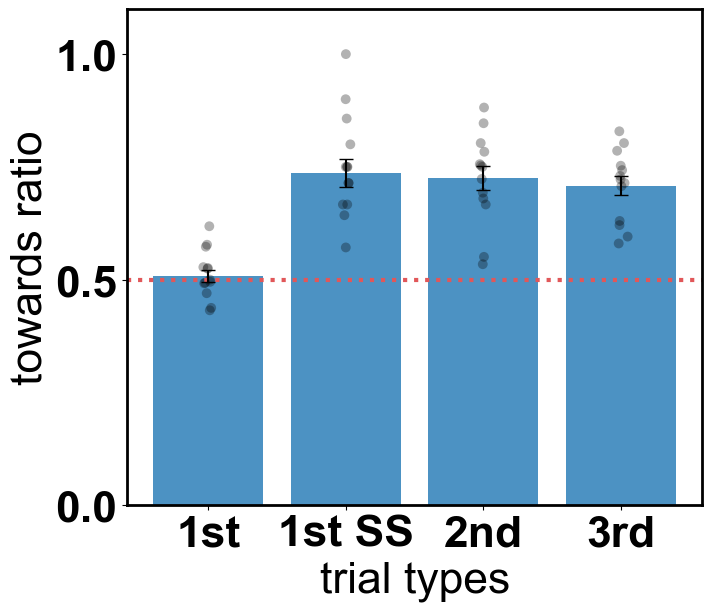

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


In [69]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(8, 7))  # Slightly wider figure

# Prepare data for original plot
results = []
individual_results = []  
conditions = []

conditions.append(('oa', 'light'))

df = con_df[~con_df['obstacle_cluster'].isin([2,3])]

# First calculate the same-side trial pair ratios (new "1st -1" data)
same_side_results = []
same_side_individual = []

for task, label in conditions:
    task_data = df[df['task'] == task]
    type0_data = task_data[task_data['consective_type'] == 0]
    
    # Find same-side trial pairs
    for idx, row in type0_data.iterrows():
        prev_idx = idx - 1
        if prev_idx in df.index:
            prev_trial = df.loc[prev_idx]
            current_cluster = row['obstacle_cluster']
            prev_cluster = prev_trial['obstacle_cluster']
            
            # Check if same side (both in 0,1 or both in 4,5)
            if ((current_cluster in [0,1] and prev_cluster in [0,1]) or 
                (current_cluster in [4,5] and prev_cluster in [4,5])):
                
                is_towards = row['turn_to_obstacle'] == 'towards'
                same_side_results.append({
                    'task': label,
                    'animal': row['animal'],
                    'is_towards': is_towards
                })

# Calculate same-side ratios
if same_side_results:
    same_side_df = pd.DataFrame(same_side_results)
    # Group level
    same_side_total = len(same_side_df)
    same_side_towards = same_side_df['is_towards'].sum()
    same_side_ratio = same_side_towards / same_side_total if same_side_total > 0 else 0
    
    # Individual level
    same_side_animal_ratios = []
    for animal in same_side_df['animal'].unique():
        animal_data = same_side_df[same_side_df['animal'] == animal]
        a_total = len(animal_data)
        a_towards = animal_data['is_towards'].sum()
        a_ratio = a_towards / a_total if a_total > 0 else 0
        same_side_animal_ratios.append(a_ratio)
        same_side_individual.append({
            'task': label,
            'type': '-1',
            'animal': animal,
            'ratio': a_ratio
        })
    
    same_side_se = np.std(same_side_animal_ratios) / np.sqrt(len(same_side_animal_ratios)) if same_side_animal_ratios else 0

# Original calculations
for task, label in conditions:
    task_data = df[df['task'] == task]
    
    for cons_type in [0, 1, 2]:
        type_data = task_data[task_data['consective_type'] == cons_type]
        
        total = len(type_data)
        towards = len(type_data[type_data['turn_to_obstacle'] == 'towards']) if total > 0 else 0
        ratio = towards / total if total > 0 else 0
        
        animal_ratios = []
        for animal in type_data['animal'].unique():
            animal_data = type_data[type_data['animal'] == animal]
            a_total = len(animal_data)
            a_towards = len(animal_data[animal_data['turn_to_obstacle'] == 'towards']) if a_total > 0 else 0
            a_ratio = a_towards / a_total if a_total > 0 else 0
            animal_ratios.append(a_ratio)
            individual_results.append({
                'task': label,
                'type': str(cons_type),
                'animal': animal,
                'ratio': a_ratio
            })
        
        se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
        
        results.append({
            'task': label,
            'type': str(cons_type),
            'ratio': ratio,
            'se': se
        })

# Combine the data
if same_side_results:
    results.append({
        'task': label,
        'type': '-1',
        'ratio': same_side_ratio,
        'se': same_side_se
    })
    individual_results.extend(same_side_individual)

results_df = pd.DataFrame(results)
individual_df = pd.DataFrame(individual_results)


# Plot settings
n_conditions = len(conditions)
bar_width = 0.8/n_conditions
colors = {'light': 'tab:blue', 'dark': '#59a14f'}

x = np.arange(4)  # Now 0, -1, 1, 2 (swapped positions)

# Plot 50% reference line
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=1, linewidth=3)

# Plot bars
for i, (task, label) in enumerate(conditions):
    # Get data in new order: 0, -1, 1, 2 (swapped positions)
    task_df = results_df[results_df['task'] == label]
    ratios = task_df.set_index('type').loc[['0','-1','1','2']]['ratio'].values  # Swapped order
    ses = task_df.set_index('type').loc[['0','-1','1','2']]['se'].values       # Swapped order
    pos = x + i*bar_width - (bar_width*n_conditions/2 - bar_width/2)
    
    # Plot bars with error bars
    bars = ax.bar(pos, ratios, bar_width,
           color=colors[label],
           label=label,
           edgecolor='none',
           alpha=0.8,
           yerr=ses,
           capsize=5)
    
    # Plot individual data points
    ind_task_df = individual_df[individual_df['task'] == label]
    for j, cons_type in enumerate(['0', '-1', '1', '2']):  # Swapped order
        type_data = ind_task_df[ind_task_df['type'] == cons_type]
        jitter = np.random.normal(0, 0.02, size=len(type_data))
        ax.scatter(pos[j] + jitter, type_data['ratio'], 
                  color='black', alpha=0.3, s=50, edgecolor='none')

# Customize plot
ax.set_xlabel('trial types')
ax.set_ylabel('towards ratio')
ax.set_xticks(x)
ax.set_xticklabels(['1st', '1st SS', '2nd', '3rd'])  # Swapped labels
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.1)

# Remove grid and frame
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)

# Add legend if showing both conditions
if n_conditions > 1:
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\towards_by_trial_type.pdf",dpi = 300, transparent=True)

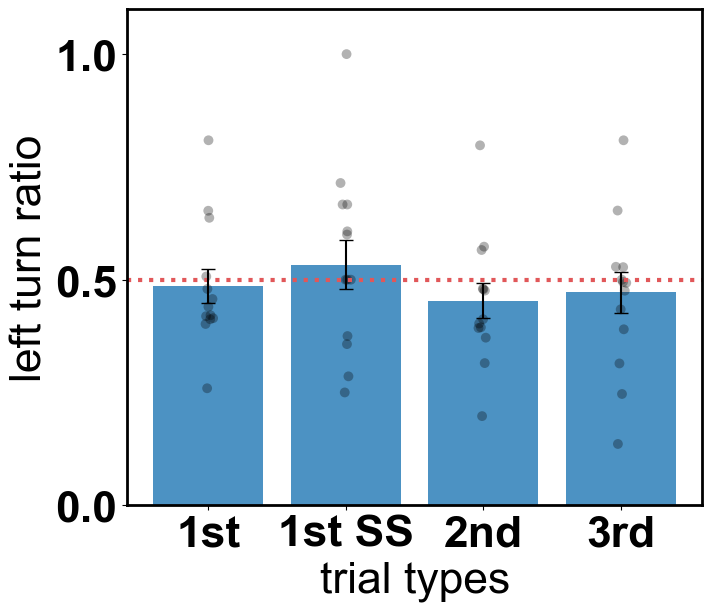

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


In [70]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(8, 7))

# Prepare data
results = []
individual_results = []  
conditions = []

conditions.append(('oa', 'light'))

df = con_df[~con_df['obstacle_cluster'].isin([2,3])]

# First calculate the same-side trial pair ratios (new "1st -1" data)
same_side_results = []
same_side_individual = []

for task, label in conditions:
    task_data = df[df['task'] == task]
    type0_data = task_data[task_data['consective_type'] == 0]
    
    # Find same-side trial pairs
    for idx, row in type0_data.iterrows():
        prev_idx = idx - 1
        if prev_idx in df.index:
            prev_trial = df.loc[prev_idx]
            current_cluster = row['obstacle_cluster']
            prev_cluster = prev_trial['obstacle_cluster']
            
            # Check if same side (both in 0,1 or both in 4,5)
            if ((current_cluster in [0,1] and prev_cluster in [0,1]) or 
                (current_cluster in [4,5] and prev_cluster in [4,5])):
                
                is_left = row['turn_direction_left_right'] == 'left'  # Changed to left turn
                same_side_results.append({
                    'task': label,
                    'animal': row['animal'],
                    'is_left': is_left
                })

# Calculate same-side ratios
if same_side_results:
    same_side_df = pd.DataFrame(same_side_results)
    # Group level
    same_side_total = len(same_side_df)
    same_side_left = same_side_df['is_left'].sum()
    same_side_ratio = same_side_left / same_side_total if same_side_total > 0 else 0
    
    # Individual level
    same_side_animal_ratios = []
    for animal in same_side_df['animal'].unique():
        animal_data = same_side_df[same_side_df['animal'] == animal]
        a_total = len(animal_data)
        a_left = animal_data['is_left'].sum()
        a_ratio = a_left / a_total if a_total > 0 else 0
        same_side_animal_ratios.append(a_ratio)
        same_side_individual.append({
            'task': label,
            'type': '-1',
            'animal': animal,
            'ratio': a_ratio
        })
    
    same_side_se = np.std(same_side_animal_ratios) / np.sqrt(len(same_side_animal_ratios)) if same_side_animal_ratios else 0

# Original calculations (now for left turns)
for task, label in conditions:
    task_data = df[df['task'] == task]
    
    for cons_type in [0, 1, 2]:
        type_data = task_data[task_data['consective_type'] == cons_type]
        
        total = len(type_data)
        left = len(type_data[type_data['turn_direction_left_right'] == 'left']) if total > 0 else 0
        ratio = left / total if total > 0 else 0
        
        animal_ratios = []
        for animal in type_data['animal'].unique():
            animal_data = type_data[type_data['animal'] == animal]
            a_total = len(animal_data)
            a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
            a_ratio = a_left / a_total if a_total > 0 else 0
            animal_ratios.append(a_ratio)
            individual_results.append({
                'task': label,
                'type': str(cons_type),
                'animal': animal,
                'ratio': a_ratio
            })
        
        se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
        
        results.append({
            'task': label,
            'type': str(cons_type),
            'ratio': ratio,
            'se': se
        })

# Combine the data
if same_side_results:
    results.append({
        'task': label,
        'type': '-1',
        'ratio': same_side_ratio,
        'se': same_side_se
    })
    individual_results.extend(same_side_individual)

results_df = pd.DataFrame(results)
individual_df = pd.DataFrame(individual_results)

# Plot settings
n_conditions = len(conditions)
bar_width = 0.8/n_conditions
colors = {'light': 'tab:blue', 'dark': '#59a14f'}

x = np.arange(4)  # Now 0, -1, 1, 2 (swapped positions)

# Plot 50% reference line
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=1, linewidth=3)

# Plot bars
for i, (task, label) in enumerate(conditions):
    # Get data in new order: 0, -1, 1, 2
    task_df = results_df[results_df['task'] == label]
    ratios = task_df.set_index('type').loc[['0','-1','1','2']]['ratio'].values
    ses = task_df.set_index('type').loc[['0','-1','1','2']]['se'].values
    pos = x + i*bar_width - (bar_width*n_conditions/2 - bar_width/2)
    
    # Plot bars with error bars
    bars = ax.bar(pos, ratios, bar_width,
           color=colors[label],
           label=label,
           edgecolor='none',
           alpha=0.8,
           yerr=ses,
           capsize=5)
    
    # Plot individual data points
    ind_task_df = individual_df[individual_df['task'] == label]
    for j, cons_type in enumerate(['0', '-1', '1', '2']):
        type_data = ind_task_df[ind_task_df['type'] == cons_type]
        jitter = np.random.normal(0, 0.02, size=len(type_data))
        ax.scatter(pos[j] + jitter, type_data['ratio'], 
                  color='black', alpha=0.3, s=50, edgecolor='none')

# Customize plot
ax.set_xlabel('trial types')
ax.set_ylabel('left turn ratio')  # Changed y-axis label
ax.set_xticks(x)
ax.set_xticklabels(['1st', '1st SS', '2nd', '3rd'])  # Using abbreviated label
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.1)

# Remove grid and frame
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)

# Add legend if showing both conditions
if n_conditions > 1:
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\leftturn_by_trial_type.pdf",dpi = 300, transparent=True)

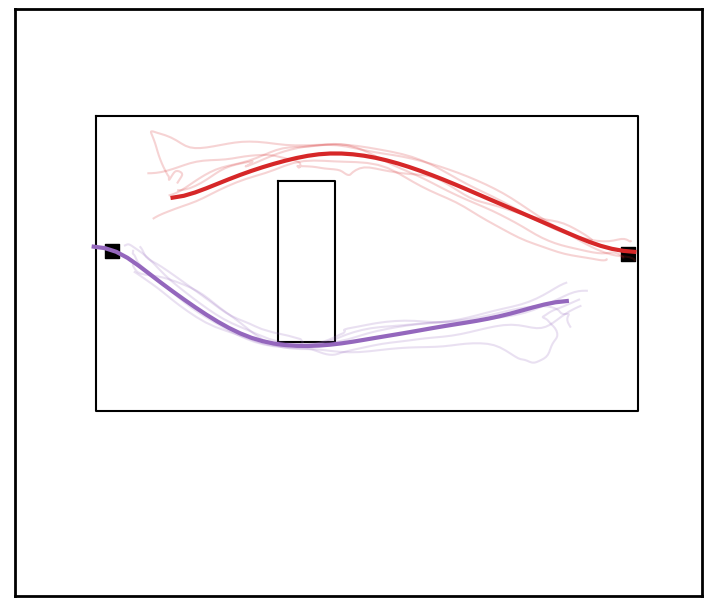

In [236]:

# Create a single subplot
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Filter the relevant data
light = con_df[
    (con_df.obstacle_cluster == 2) &
    (con_df.task == 'oa') &
    (con_df.obstacle_cross == True)
]

# Filter for the sample animals
light_sample_towards = light[light['animal'].isin([
    'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
    'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'
])]

# Select first and second trials
first_trial = light_sample_towards[
    (light_sample_towards.consective_type == 1) &
    (light_sample_towards.odd == 'right')&(light_sample_towards.start == 'bottom')
]

sec_trial = light_sample_towards[
    (light_sample_towards.consective_type == 2) &
    (light_sample_towards.odd == 'left')&(light_sample_towards.start == 'top')
]

# Get median trajectories
first_nose_y, first_nose_x = get_median_trajectory(first_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
sec_nose_y, sec_nose_x = get_median_trajectory(sec_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')

# Plot arena and obstacle (just once)
plot_arena(light_sample_towards, ax)
ob_x, ob_y = plot_orginal_obstacle(first_trial, ax, 1)

# Plot median trajectories
ax.plot(first_nose_x, smooth(first_nose_y,2), c='tab:purple', linewidth=3, label='First Trial (Type 0, Right)')
ax.plot(sec_nose_x, smooth(sec_nose_y,2), c='tab:red', linewidth=3, label='Second Trial (Type 1, Left)')

# Overlay 10 sample smoothed trajectories from each
for _, row in first_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:purple', alpha=0.2)

for _, row in sec_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:red', alpha=0.2)

# Finalize plot
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\biomechanic_middle.pdf",dpi = 300, transparent=True)

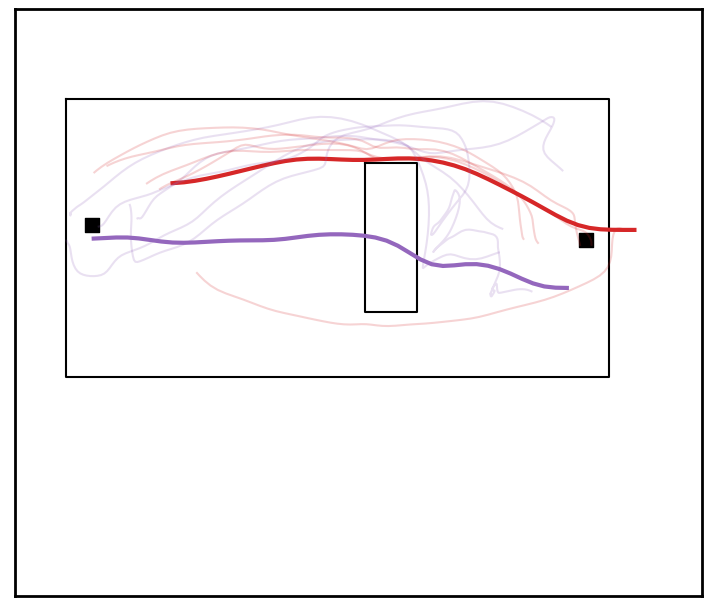

In [217]:

# Create a single subplot
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Filter the relevant data
light = con_df[
    (con_df.obstacle_cluster == 3) &
    (con_df.task == 'oadark') &
    (con_df.obstacle_cross == True)
]

# Filter for the sample animals
light_sample_towards = light[light['animal'].isin([
    'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
    'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'
])]

# Select first and second trials
first_trial = light_sample_towards[
    (light_sample_towards.consective_type == 0) &
    (light_sample_towards.odd == 'right')
]

sec_trial = light_sample_towards[
    (light_sample_towards.consective_type == 1) &
    (light_sample_towards.odd == 'left')
]

# Get median trajectories
first_nose_y, first_nose_x = get_median_trajectory(first_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
sec_nose_y, sec_nose_x = get_median_trajectory(sec_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')

# Plot arena and obstacle (just once)
plot_arena(light_sample_towards, ax)
ob_x, ob_y = plot_orginal_obstacle(first_trial, ax, 1)

# Plot median trajectories
ax.plot(first_nose_x, smooth(first_nose_y,2), c='tab:purple', linewidth=3, label='First Trial (Type 0, Right)')
ax.plot(sec_nose_x, smooth(sec_nose_y,2), c='tab:red', linewidth=3, label='Second Trial (Type 1, Left)')

# Overlay 10 sample smoothed trajectories from each
for _, row in first_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:purple', alpha=0.2)

for _, row in sec_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:red', alpha=0.2)

# Finalize plot
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

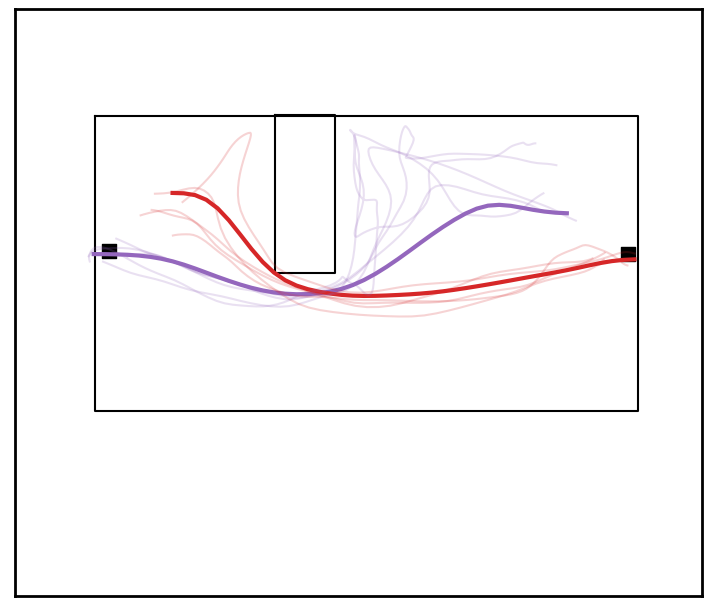

In [239]:
# Create a single subplot
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Filter the relevant data
light = con_df[
    (con_df.obstacle_cluster == 0) &
    (con_df.task == 'oa') &
    (con_df.obstacle_cross == True)
]

# Filter for the sample animals
light_sample_towards = light[light['animal'].isin([
    'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN',
    'G8CK1LN', 'G8CK1LT', 'G8CK1RT', 'G8CK1TT'
])]

# Select first and second trials
first_trial = light_sample_towards[
    (light_sample_towards.consective_type == 1) &
    (light_sample_towards.odd == 'right')
]

sec_trial = light_sample_towards[
    (light_sample_towards.consective_type == 2) &
    (light_sample_towards.odd == 'left')
]

# Get median trajectories
first_nose_y, first_nose_x = get_median_trajectory(first_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
sec_nose_y, sec_nose_x = get_median_trajectory(sec_trial, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')

# Plot arena and obstacle (just once)
plot_arena(light_sample_towards, ax)
ob_x, ob_y = plot_orginal_obstacle(first_trial, ax, 1)

# Plot median trajectories
ax.plot(first_nose_x, smooth(first_nose_y,2), c='tab:purple', linewidth=3, label='First Trial (Type 0, Right)')
ax.plot(sec_nose_x, smooth(sec_nose_y,2), c='tab:red', linewidth=3, label='Second Trial (Type 1, Left)')

# Overlay 10 sample smoothed trajectories from each
for _, row in first_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:purple', alpha=0.2)

for _, row in sec_trial.sample(5).iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax.plot(smooth(x), smooth(y), c='tab:red', alpha=0.2)

# Finalize plot
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\biomechanic_edge.pdf",dpi = 300, transparent=True)